Here's the file I'm gonna use for PTDE stuff! It sure sucks that I'll have to rewrite a bunch of stuff, but c'est la vie

So we'll start by modeling a PTDE event as the secondary object splitting into two objects: a small fraction that we say gets put into a circular or parabolic orbit (call this the disrupted portion) and the much larger remainder (call this the remaining secondary), which we continue to track. This is a HEAVY simplification of a real system, which would have some amount of its mass scattered into a range of orbits between essentially circular and unbound orbits, but for now we can use this as our base model and potentially iterate on it later. If we don't think about it too hard, we can probably say we're treating the disrupted as the cumulative effect of the true loss, simplified. 

Putting that aside, one thing that does concern me is the inclination aspect. It's easy to say that an equatorial orbit, or an inclined schwarzschild orbit, would have all of its material remain in the same plane, but could that potentially be different for an inclined kerr orbit? Could the disrupted portion be ejected in a way that gives the remaining secondary a different inclination? I'm tempted to say 'maybe, probably not' based off of unsupported intuition, but we'll table this for now and just assume that the dirupted portion is set on a circular orbit with the same inclination as the original secondary body.

Keeping all that in mind, the process for implementing this are very simple:

0) Run an orbit until the secondary body reaches periapse; the 4-momentum for the secondary body is $p$
1) Calculate the 4-momentum $p_d$ for a circular (parabolic) orbit with that radius (periapse) and the appropriate inclination at that point
2) Determine the 4-momentum $p_r$ for the remaining secondary by solving for the inelastic collision
3) Profit

First thing I actually have to do is make sure I can actually do parabolic orbits! That should be the same as just setting E=1 right? 
I cannot DO parabolic orbits (without serious structural changes), but I don't need to! I can calculate the state OF a parabolic orbit at a particular point, so that's all I need! Let's try making a function, then we'll test it out a bit.
Turns out theres absolutely no need to convert to cartesian, which simplifies things a lot. Lucky me! If only I'd looked that up hours ago!

Implementing the parabolic disrupted portion has turned out to be a little more complicated than I expected, since all my code is set up for bound orbits and complains a lot otherwise. I think it's still workable, but I'll need to do math. That will go in the new notebook.

Normalizing initial state


10083291.48360323it [00:02, 3601077.16it/s, Semilat: 11.342, Ecc 0.547, Peri: 7.333]                             
10076084.881699331it [00:02, 4789507.40it/s, Semilat: 10.354, Ecc 0.726, Peri: 5.999]                             
10036314.512334615it [00:00, 124558313.94it/s, Semilat: 10.531, Ecc 0.753, Peri: 6.009]                             
10009868.417451156it [00:00, 116899432.39it/s, Semilat: 10.725, Ecc 0.781, Peri: 6.02]                             
 15%|█▍        | 1496139.22509366/10000000 [00:00<00:00, 14639288.42it/s, Semilat: (8.615+0j), Ecc (0.437-0j), Peri: (5.995+0j)]  


1.8662082343255644 1.866212006324817


 20%|██        | 2007356.1358978401/10000000 [00:00<00:00, 20089242.67it/s, Semilat: (8.608+0j), Ecc (0.434-0j), Peri: (6.002+0j)]


1.8662053705168875 1.866212006324817


 37%|███▋      | 3704688.215397988/10000000 [00:00<00:00, 37057873.25it/s, Semilat: (8.601+0j), Ecc (0.431-0j), Peri: (6.01+0j)]


1.8661964628039371 1.866212006324817


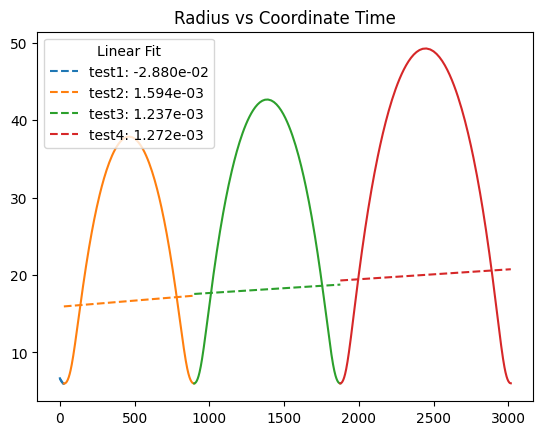

Could not plot linear fit.


C:\Users\camcinto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_polynomial_impl.py:657: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


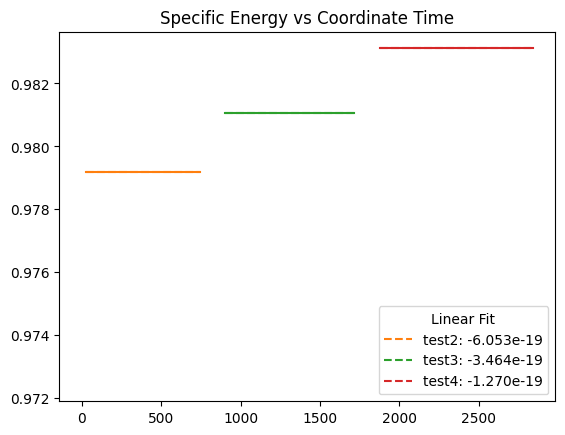

Could not plot linear fit.


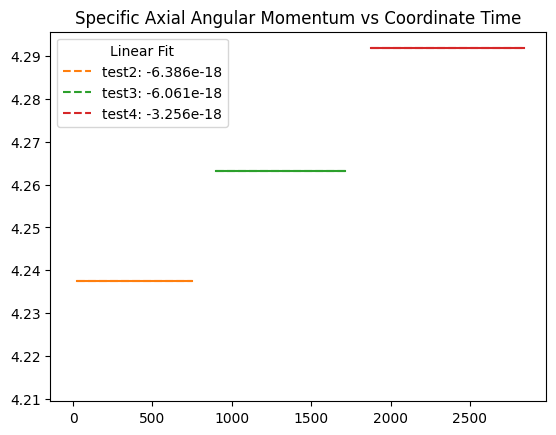

Could not plot linear fit.


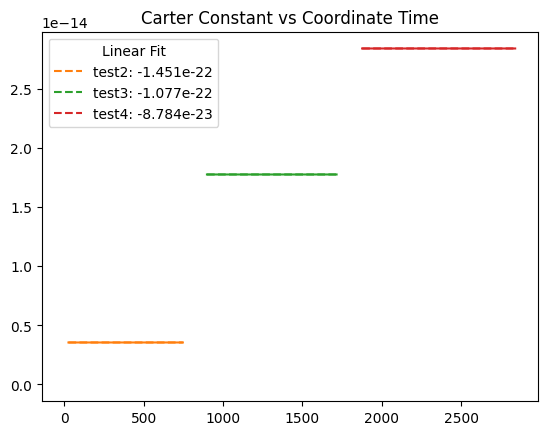

In [215]:
import MetricMathStreamline as mm
import MainLoopStreamline as ml
import OrbitPlotter as op
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
import importlib
importlib.reload(ml)
importlib.reload(mm)

def disrupt_particle(spin, state, mass_percent=0.1, circ_loss=True):
    cons = ml.getCons_2(state, spin)
    turns, flats, zs = mm.root_getter(*cons, spin)
    inc = np.arccos(min(1.0, np.mean(np.abs(zs[1:3]))))
    if circ_loss == True:
        dir_tog = np.sign(cons[1])**np.sign(cons[1])           # negative if L is negative, positive otherwise
        dis_state = mm.set_u_kerr(spin, params=[state[1], 0.0, dir_tog*inc], pos=state[:4])[0]
        result_state = np.array([*state[:4], *(state[4:] - mass_percent*dis_state[4:])/(1 - mass_percent)])
    else:
        g = lambda r, a: 2*a*r
        h = lambda r, a, z: r*(r - 2) + (r**2 - 2*r + a**2)*(z**2)/(1 - z**2)
        j = lambda r, a: 2*r*(r**2 + a**2)
        L_pro = lambda r, a, z: (-1/h(r, a, z))*(g(r, a) - np.sqrt(g(r,a)**2 + h(r, a, z)*j(r, a)))
        L_ret = lambda r, a, z: (-1/h(r, a, z))*(g(r, a) + np.sqrt(g(r,a)**2 + h(r, a, z)*j(r, a)))
        L = L_pro(state[1], spin, np.cos(inc)) if cons[1] >= 0 else L_ret(state[1], spin, np.cos(inc))
        C = L*L*(np.cos(inc)**2)/(1 - np.cos(inc)**2)
        dis_state = mm.set_u_kerr(spin, cons=[1.0, L, C], pos=state[:4])[0]
        result_state = np.array([*state[:4], *(state[4:] - mass_percent*dis_state[4:])/(1 - mass_percent)])
    return dis_state, result_state

a = -0.5
state = mm.set_u_kerr(a, params=[6, 0.3, np.pi/2])[0]
#print(state)
#state_rev = state*np.array([1,1,1,1,1,1,1,-1])
#print(state_rev)
##print(state)
#print(disrupt_particle(0.0, state))
#print(disrupt_particle(0.0, state_rev))
e = 0.1
circ = True
test1 = ml.EMRIGenerator(a, 1e-7, endflag=f"radius <= 6.0001", params=[6/(1 - e), e, np.pi/2], label=f"test1", trigger=2, err_target=1e-10)
circ1, newstate = disrupt_particle(a, test1["raw"][-1], circ_loss=circ)
test2 = ml.EMRIGenerator(a, 0.9*1e-7, endflag=f"rad_orbit >= 1", pos=newstate[:4], veltrue=newstate[4:], label=f"test2", trigger=2, err_target=1e-10)
circ2, newstate = disrupt_particle(a, test2["raw"][-1], circ_loss=circ)
test3 = ml.EMRIGenerator(a, 0.9*0.9*1e-7, endflag=f"rad_orbit >= 1", pos=newstate[:4], veltrue=newstate[4:], label=f"test3", trigger=2, err_target=1e-10)
circ3, newstate = disrupt_particle(a, test3["raw"][-1], circ_loss=circ)
test4 = ml.EMRIGenerator(a, 0.9*0.9*0.9*1e-7, endflag=f"rad_orbit >= 1", pos=newstate[:4], veltrue=newstate[4:], label=f"test4", trigger=2, err_target=1e-10)
circ1 = ml.EMRIGenerator(a, 0.1*1e-7, endflag=f"time >= {test4["time"][-1] - circ1[0]}", pos=circ1[:4], veltrue=circ1[4:], label=f"circ1", trigger=2, err_target=1e-10)
circ2 = ml.EMRIGenerator(a, 0.1*0.9*1e-7, endflag=f"time >= {test4["time"][-1] - circ2[0]}", pos=circ2[:4], veltrue=circ2[4:], label=f"circ2", trigger=2, err_target=1e-10)
circ3 = ml.EMRIGenerator(a, 0.1*0.9*0.9*1e-7, endflag=f"time >= {test4["time"][-1] - circ3[0]}", pos=circ3[:4], veltrue=circ3[4:], label=f"circ3", trigger=2, err_target=1e-10)

op.plotvalue3([test1, test2, test3, test4], "time", "radius")
op.plotvalue3([test1, test2, test3, test4], "tracktime", "energy")
op.plotvalue3([test1, test2, test3, test4], "tracktime", "L_z")
op.plotvalue3([test1, test2, test3, test4], "tracktime", "carter")


Okay! I'm reasonably happy with how this function works, it seems like it should cover all of my needs. However, there is a problem(?) in that I can't always guarantee that I'm as close as I can reasonably get to the periapse when I make the disruption, which might not be *super* important but is probably worth at least looking into. Two ways I immediately think of to handle this are:
1) Go into EMRIGenerator and tweak the endflag handling to reach the periapse with the program, or
2) Wait until the run is finished, then use some form of interpolation to get to the true periapse.

Personally, option 2 is probably easier, though I might want to mess with the endflag handling later anyway. So, how will this work? I'm thinking that I can take the chunk of radial data around the periapse, approximate it to a quadratic, find the minimum, and then just interpolate all the other values to match the appropriate timestamp. Let's see if we can make that work!

The ideal way to do this is if I have data on both sides of the periapse, which is deceptively hard to guarantee for the very first orbit. If I let it start from the default, which is more or less the potential minimum, having it stop after some percentage of a radial orbit is workable (it should always be between 0.25 and 0.5) but inconsistent, since the potential minimum doesn't necessarily correspond to any particular part of a radial orbit. That might be a rabbit hole, though.

Alright, I think I found my method! Now to package it into a nice little function.

Normalizing initial state


10006279.227452332it [00:00, 43224887.06it/s, Semilat: 7.7, Ecc 0.1, Peri: 7.0]                             


111
291
[ 3.56488613e+02  7.00251749e+00  1.57079633e+00  1.68958081e+01
  1.32690904e+00 -1.81121333e-03 -1.52548428e-13  7.25096651e-02]
[ 3.60140915e+02  7.00000019e+00  1.57079633e+00  1.70954663e+01
  1.32709984e+00 -1.69882511e-05 -1.44471966e-13  7.25618256e-02]
[ 3.64256909e+02  7.00308489e+00  1.57079633e+00  1.73204640e+01
  1.32686606e+00  2.00454653e-03 -1.28282829e-13  7.24979160e-02]
[360.17391723]
[7.00000849]
[ 3.60173917e+02  7.00000849e+00  1.57079633e+00  1.70972011e+01
  1.32709858e+00 -4.55460945e-06 -1.44437173e-13  7.25614682e-02]


10072421.947708867it [00:00, 157287523.51it/s, Semilat: 7.765, Ecc 0.109, Peri: 7.003]                             


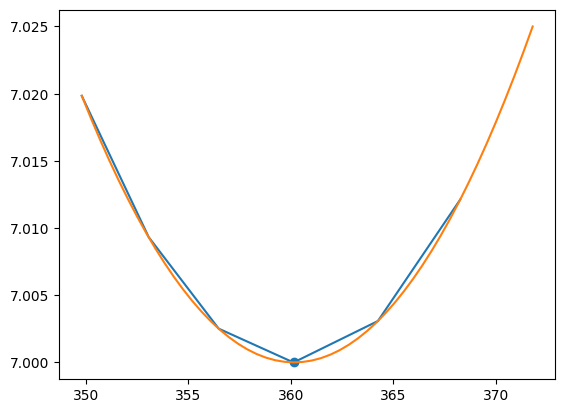

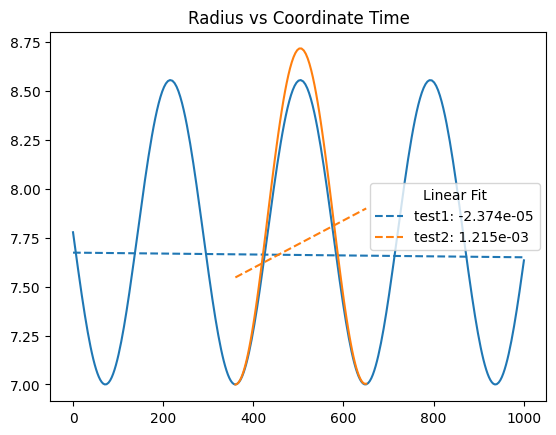

[ 3.60173917e+02  7.00000849e+00  1.57079633e+00  1.70972011e+01
  1.32709858e+00 -4.55460945e-06 -1.44437173e-13  7.25614682e-02]
[ 9.36947305e+02  7.00001109e+00  1.57079633e+00  4.39113495e+01
  1.32709819e+00 -6.64350201e-06 -6.06144934e-14  7.25613587e-02]


In [334]:
test1 = ml.EMRIGenerator(0.0, 1e-7, endflag=f"rad_orbit >= 3.5", params=[7/(1 - 0.1), 0.1, np.pi/2], label=f"test1", trigger=2, err_target=1e-10)
#op.plotvalue3(test1, "time", "radius")
#op.plotvalue3(test1, "time", "radius", derv=1)
ix = op.get_index(test1["raw"][:,1], 0)
print(ix)
print(len(test1["time"]))
print(test1["raw"][ix-1])
print(test1["raw"][ix])
print(test1["raw"][ix+1])
tp = np.roots(np.polyder(np.polyfit(test1["time"][ix-3:ix+3], test1["raw"][ix-3:ix+3,1], 2),1))
plt.plot(test1["time"][ix-3:ix+3], test1["raw"][ix-3:ix+3,1])
plt.plot(np.linspace(test1["time"][ix-3], test1["time"][ix+3]), np.polyval(np.polyfit(test1["time"][ix-3:ix+3], test1["raw"][ix-3:ix+3,1], 2), np.linspace(test1["time"][ix-3], test1["time"][ix+3])))
print(tp)
print(np.polyval(np.polyfit(test1["time"][ix-3:ix+3], test1["raw"][ix-3:ix+3,1], 2), tp))
plt.scatter(tp, np.polyval(np.polyfit(test1["time"][ix-3:ix+3], test1["raw"][ix-3:ix+3,1], 2), tp))

peri_state = np.array([np.polyval(np.polyfit(test1["time"][ix-3:ix+3], test1["raw"][ix-3:ix+3, i], 2), tp)[0] for i in range(8)])
print(peri_state)
circ1, newstate = disrupt_particle(0.0, peri_state)
test2 = ml.EMRIGenerator(0.0, 0.9*1e-7, endflag=f"rad_orbit >= 1", pos=newstate[:4], veltrue=newstate[4:], label=f"test2", trigger=2, err_target=1e-10)
#circ1 = ml.EMRIGenerator(a, 0.1*1e-7, endflag=f"time >= {test2["time"][-1] - circ1[0]}", pos=circ1[:4], veltrue=circ1[4:], label=f"circ1", trigger=2, err_target=1e-10)

op.plotvalue3([test1, test2], "time", "radius")

def get_peri_state(data):
    #index of the closest point to the most recent periapse
    try:
        ix = data["trackix"][-1] + op.get_index(data["raw"][data["trackix"][-1]:,1], 0)
    except:
        ix = op.get_index(data["raw"][:,1], 0)
    offset = len(data["time"]) - ix
    if offset >= 3:
        a, b = -3, 3
    else:
        a, b = -6 + offset, offset
    #print(data["time"][ix + a:ix + b], "time")
    #print(data["raw"][ix +a:ix + b,1], "radius")
    #print(a, b, ix)
    p = np.polyfit(data["time"][ix + a:ix + b], data["raw"][ix +a:ix + b,1], 2)
    tp = np.roots(np.polyder(p, 1))
    peri_state = np.array([np.polyval(np.polyfit(data["time"][ix + a:ix + b], data["raw"][ix + a:ix + b, i], 2), tp)[0] for i in range(8)])
    return peri_state

print(peri_state)
print(get_peri_state(test1))



Okay! Now that that's done, I can put together a much bigger program-thing that can handle an orbit and do the peeling based on that. In theory I could do some stuff that involves calculating tidal radii and all that jazz, but since this is really just the proof of concept, I'll use Anna Payne's thing and base the orbit off of that as best as I can.

Central Black Hole Mass ~ 10^7.85 solar masses
Period ~ 114.2 days = 28350 time units
Semimajor axis = ((P^2)/(4*pi^2))^(1/3) ~ 273 distance units
I can get an approximate eccentricity based on the tidal disruption radius, but:
Tidal disruption radius ~ R_star*((M_bh/M_star)^1/3) 
I need a model for the actual star! Lets call it solar mass, but inflated to 10 times the normal radius because of giant stuff.
M_bh/M_star ~ 10^7.85
R_star ~ 0.006661326693863723 distance units
Tidal disruption radius ~ 27.55671217415061
eccentricity ~ 0.899

Normalizing initial state


10001362.86643492it [00:00, 10876584.39it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                              


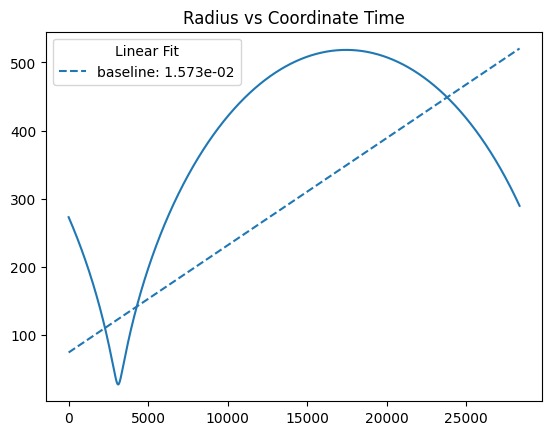

In [321]:
baseline = ml.EMRIGenerator(0.0, 1/(10**7.85), endflag=f"time >= 28350", params=[273, 0.899, np.pi/2], label=f"baseline", trigger=2, err_target=1e-15)
op.plotvalue3(baseline, "time", "radius")

Okay, that's done, easy peasy! Now a quick wrapper function that lets me run this whole thing with various disruption fractions and ejection modes (circular vs hyperbolic)

-2 True
-3 True
-4 True
-5 True
-6 True
-7 True
-8 True
-9 True
-2 False


10005129.15612087it [00:01, 9495742.37it/s, Semilat: 52.333, Ecc 0.898, Peri: 27.573]                                
10002672.866128832it [00:01, 8640544.62it/s, Semilat: 52.305, Ecc 0.897, Peri: 27.573]                              
10005386.225826906it [00:01, 7731391.83it/s, Semilat: 52.277, Ecc 0.896, Peri: 27.574]                               
10001219.057176918it [00:01, 9380898.95it/s, Semilat: 52.248, Ecc 0.895, Peri: 27.574]                               
10001365.505611446it [00:01, 9257368.89it/s, Semilat: 52.219, Ecc 0.894, Peri: 27.574]                              
10000042.1579836it [00:01, 9492033.40it/s, Semilat: 52.19, Ecc 0.893, Peri: 27.574]                                 
10000281.32602872it [00:01, 9330577.29it/s, Semilat: 52.16, Ecc 0.892, Peri: 27.575]                                
10003015.96832357it [00:00, 10013319.82it/s, Semilat: 52.13, Ecc 0.891, Peri: 27.575]                               
10000230.92757423it [00:01, 7793715.67it/s, Semilat: 52.1, Ec

Don't trust this! -33.14474240283016 [1.0, 0.0, np.float64(1.6944394731841233e-09), 'rad_orbit >= 1.2', 1e-15, 'frac:0.01, False 211', False, False, False, False, [1826011.3980315805, 31.29982329159975, 1.5707967533462615, 1421.1773956320194], [1.051999065033232, -2.858060588412101e-09, -1.9454711716083554e-08, 0.006064804547823469], 'grav']


 65%|██████▌   | 6535036.601357222/10000000 [00:00<00:00, 58845984.91it/s, Semilat: (31.993+0j), Ecc 0.034j, Peri: (31.957-1.076j)]

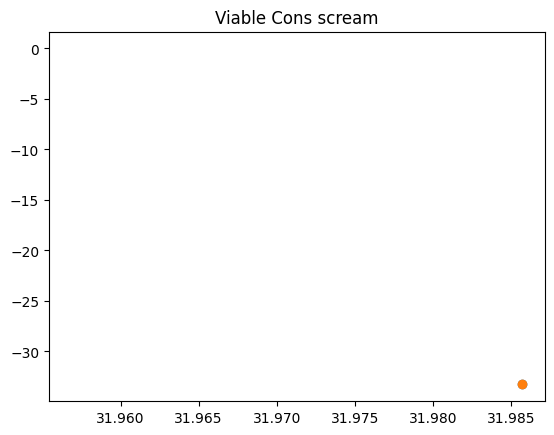

 74%|███████▍  | 7380599.92128077/10000000 [00:00<00:00, 14752758.25it/s, Semilat: (31.993+0j), Ecc 0.034j, Peri: (31.957-1.076j)] 

BADVALS 0.9847782979872252 5.941561279105939 3.696811745612649e-10

Ending program
-3 False



10002141.018747665it [00:01, 9713272.02it/s, Semilat: 52.358, Ecc 0.899, Peri: 27.573]                               
c:\Users\camcinto\OneDrive - NASA\Documents\Github\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invalid value encountered in sqrt
  inc = np.arccos(np.sqrt(z2))
10003128.926485443it [00:01, 7368988.91it/s, Semilat: 52.356, Ecc 0.899, Peri: 27.573]                               
10000018.911616802it [00:01, 9251061.47it/s, Semilat: 52.353, Ecc 0.899, Peri: 27.573]                               
10005019.383205717it [00:01, 9461481.55it/s, Semilat: 52.35, Ecc 0.899, Peri: 27.573]                               
10003758.474509249it [00:01, 9350632.69it/s, Semilat: 52.347, Ecc 0.898, Peri: 27.573]                               
10005438.200923158it [00:01, 7783678.30it/s, Semilat: 52.345, Ecc 0.898, Peri: 27.573]                               
10000921.401694594it [00:01, 9837354.98it/s, Semilat: 52.342, Ecc 0.898, Peri: 27.573]                              

-4 False


10005583.733209658it [00:01, 9852114.23it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
10004687.9721268it [00:01, 7953654.71it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                                 
c:\Users\camcinto\OneDrive - NASA\Documents\Github\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invalid value encountered in sqrt
  inc = np.arccos(np.sqrt(z2))
10002472.234233202it [00:01, 9633815.99it/s, Semilat: 52.36, Ecc 0.899, Peri: 27.573]                              
10003611.178510034it [00:01, 9343011.88it/s, Semilat: 52.36, Ecc 0.899, Peri: 27.573]                               
10000172.527730864it [00:01, 7226313.49it/s, Semilat: 52.36, Ecc 0.899, Peri: 27.573]                               
10001913.372925058it [00:01, 8814808.26it/s, Semilat: 52.359, Ecc 0.899, Peri: 27.573]                               
10003976.322211932it [00:01, 8572769.00it/s, Semilat: 52.359, Ecc 0.899, Peri: 27.573]                               
10

...

10002092.53216805it [00:01, 9634109.54it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                                
c:\Users\camcinto\OneDrive - NASA\Documents\Github\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invalid value encountered in sqrt
  inc = np.arccos(np.sqrt(z2))
10002921.832893094it [00:00, 10090612.86it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                              
10003125.264504552it [00:01, 9800981.24it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
10003133.18464345it [00:01, 7738428.66it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                                
c:\Users\camcinto\OneDrive - NASA\Documents\Github\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invalid value encountered in sqrt
  inc = np.arccos(np.sqrt(z2))
10005207.317265028it [00:01, 9420026.65it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
10002168.243913416it [00:01, 9818718.53it/s, Semilat: 52.3

-8 False


10002694.062287139it [00:01, 7918481.43it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
c:\Users\camcinto\OneDrive - NASA\Documents\Github\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invalid value encountered in sqrt
  inc = np.arccos(np.sqrt(z2))
10000463.943528164it [00:01, 9676930.88it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
c:\Users\camcinto\OneDrive - NASA\Documents\Github\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invalid value encountered in sqrt
  inc = np.arccos(np.sqrt(z2))
10004385.609663207it [00:01, 9068560.29it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
c:\Users\camcinto\OneDrive - NASA\Documents\Github\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invalid value encountered in sqrt
  inc = np.arccos(np.sqrt(z2))
10004624.396302368it [00:01, 7802826.10it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               


-9 False


10003764.530081023it [00:01, 9280662.17it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
10001377.831651047it [00:01, 7311896.65it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
10004320.586505521it [00:01, 9485897.55it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
10003690.907160243it [00:01, 9406495.73it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
c:\Users\camcinto\OneDrive - NASA\Documents\Github\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invalid value encountered in sqrt
  inc = np.arccos(np.sqrt(z2))
10004830.649370091it [00:01, 7333942.56it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                              
10000380.579753885it [00:01, 8085934.36it/s, Semilat: 52.361, Ecc 0.899, Peri: 27.573]                               
c:\Users\camcinto\OneDrive - NASA\Documents\Github\Black-Hole-Stuff\MainLoopStreamline.py:512: RuntimeWarning: invali

In [381]:
def do_thing(mass_frac, dis_circ):
    data = baseline.copy()
    datalist = [data]
    i = 1
    while data["time"][-1] < 3000000 and data["stop"] == False:
        peri = get_peri_state(data)
        _, newstate = disrupt_particle(data["spin"], peri, mass_frac, dis_circ)
        data = ml.EMRIGenerator(data["spin"], ((1 - mass_frac)**i)/(10**7.85), endflag=f"rad_orbit >= 1.2", pos=newstate[:4], veltrue=newstate[4:], label=f"frac:{mass_frac}, {dis_circ} {i}", trigger=2, err_target=1e-15)
        datalist.append(data)
        i += 1
    return datalist

#master_dict.keys() 
#master_dict = {}
for circ in [True, False]:
    for i in -np.arange(2, 10):
        print(i, circ)
        if (i, circ) not in master_dict.keys():
            master_dict[(i, circ)] = do_thing(10.0**i, circ)


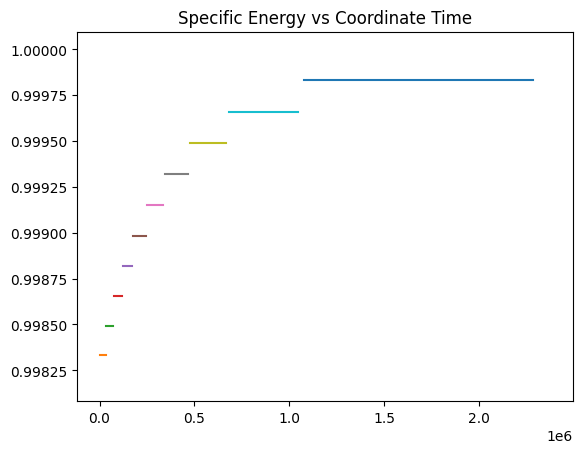

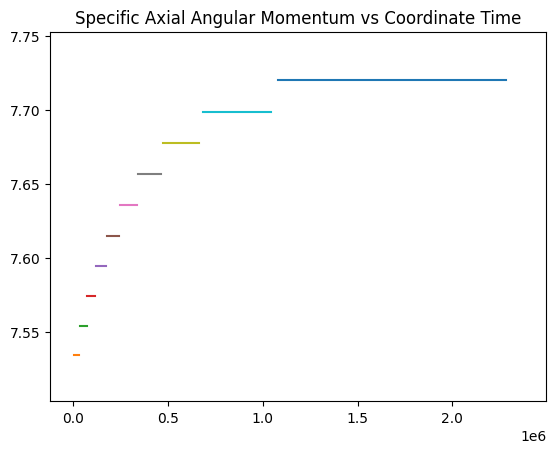

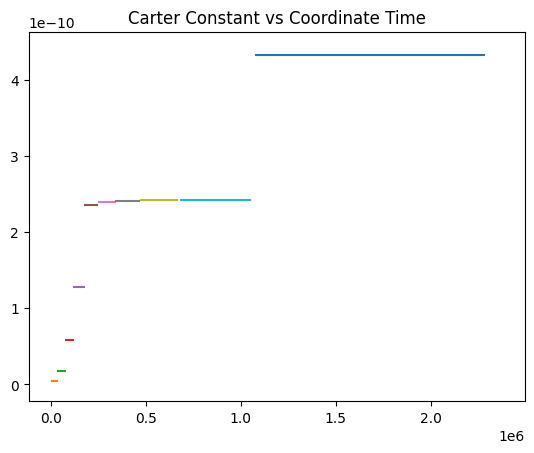

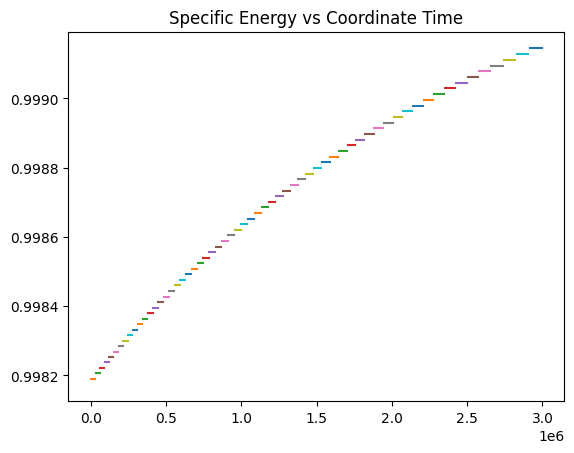

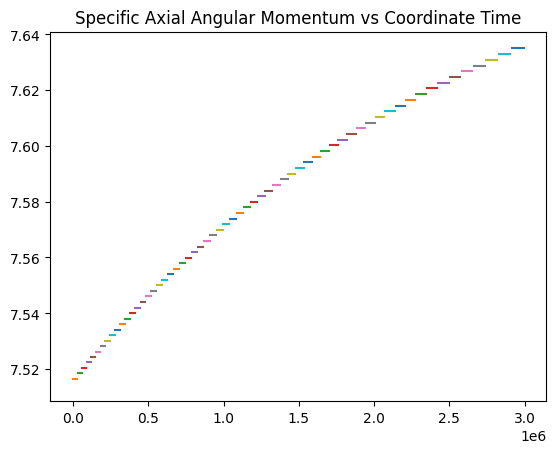

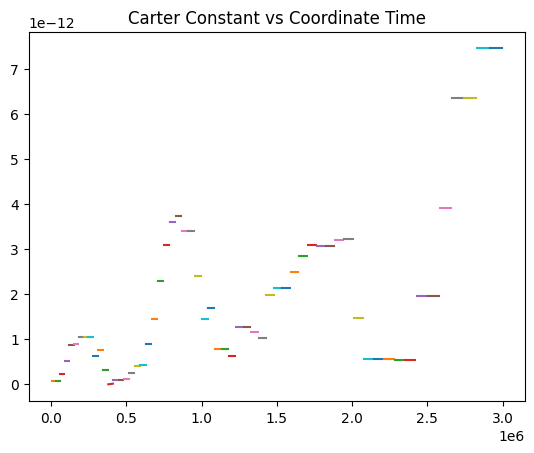

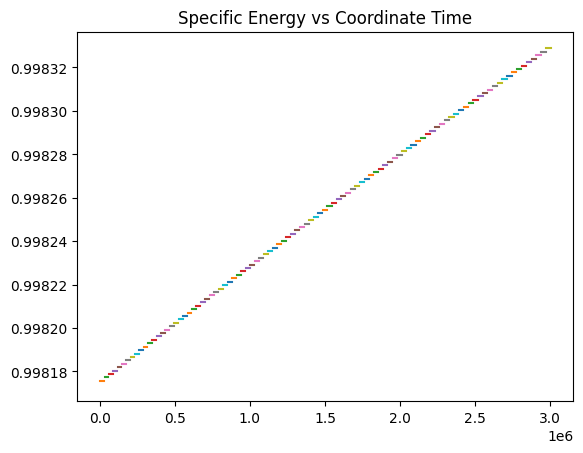

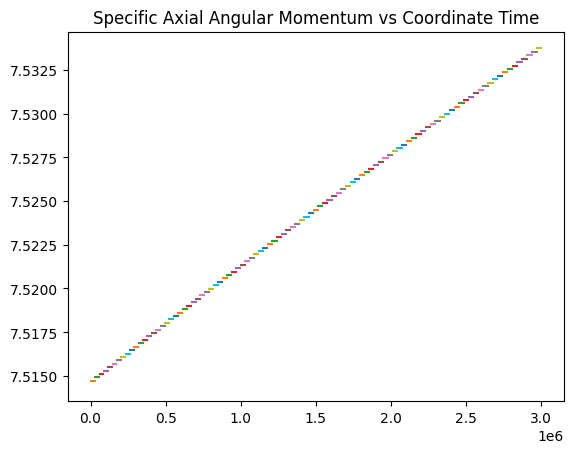

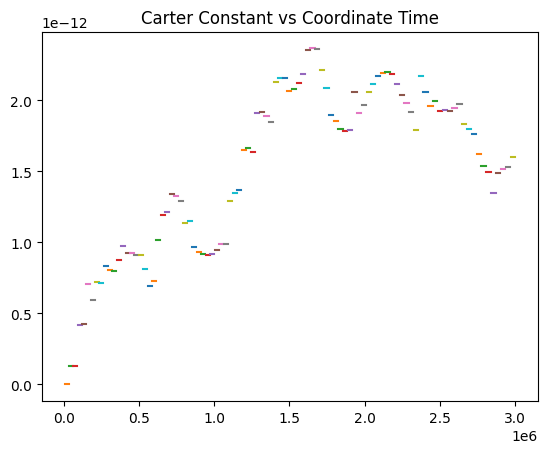

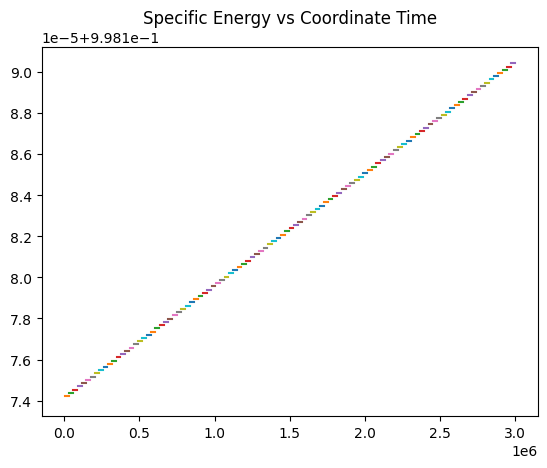

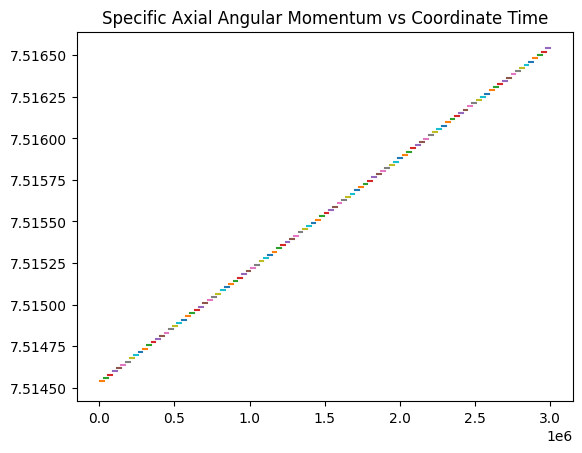

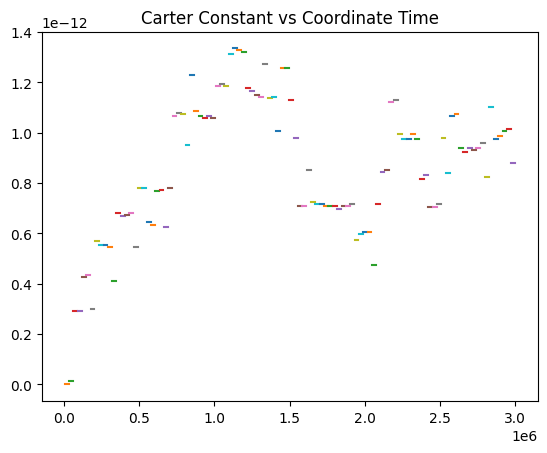

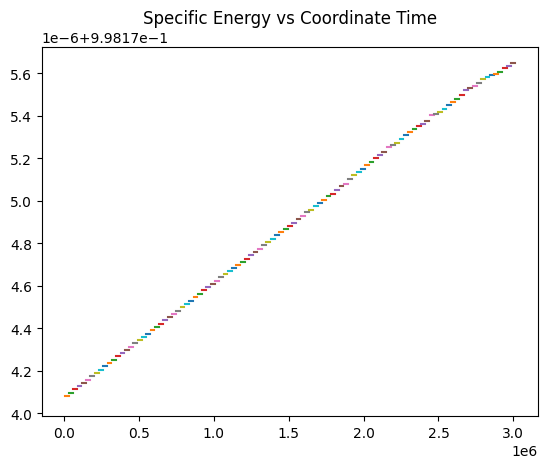

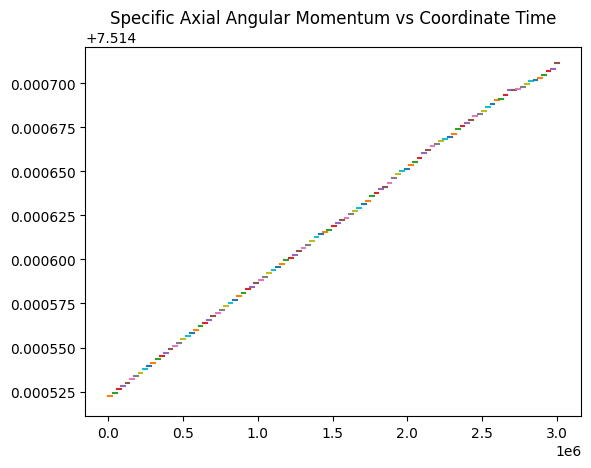

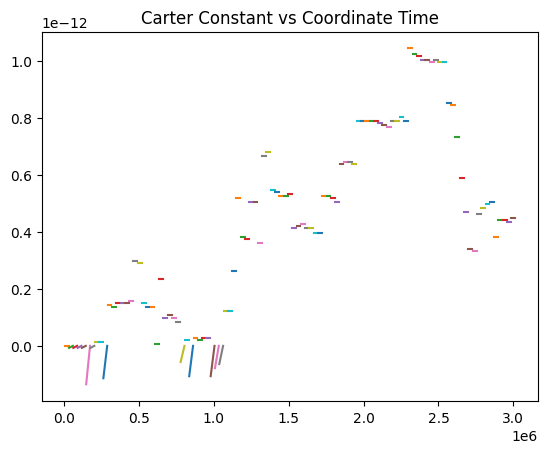

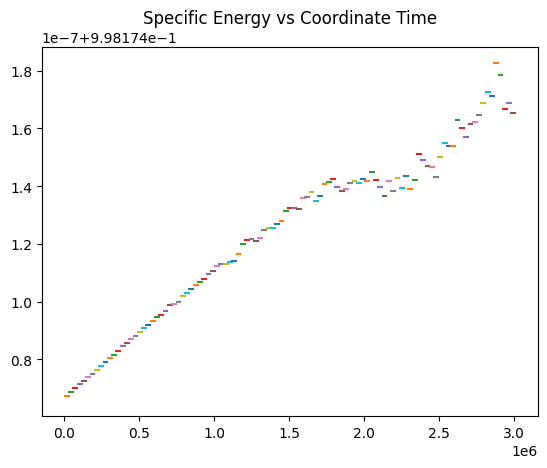

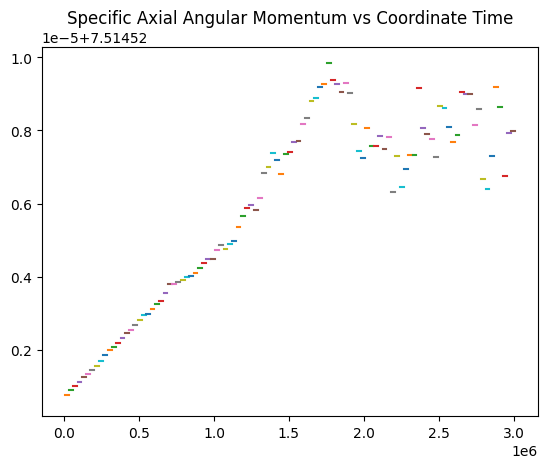

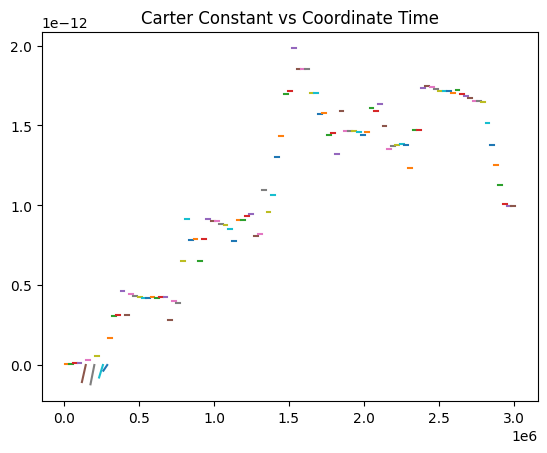

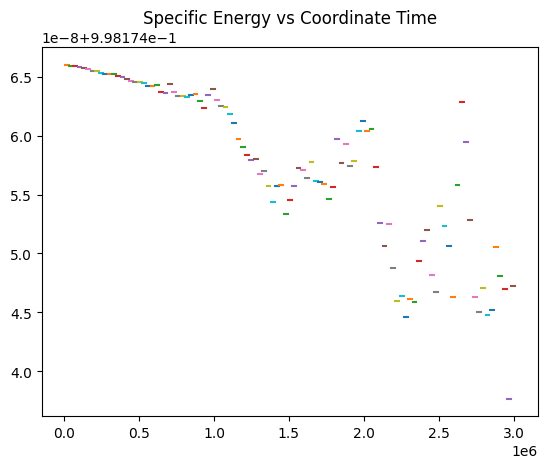

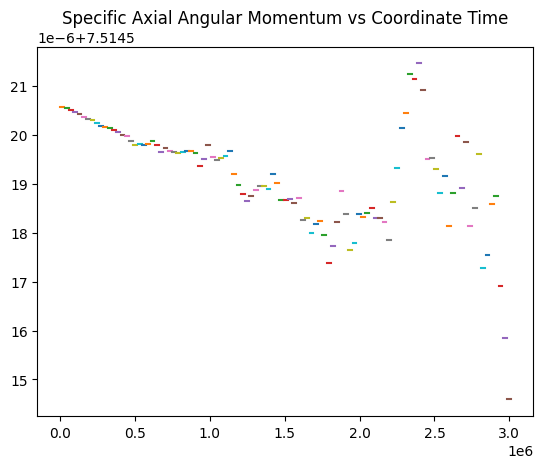

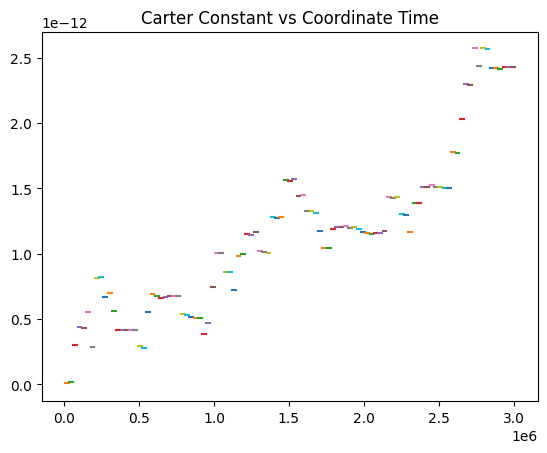

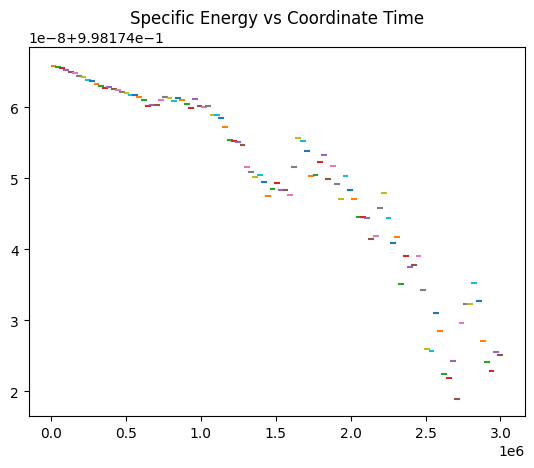

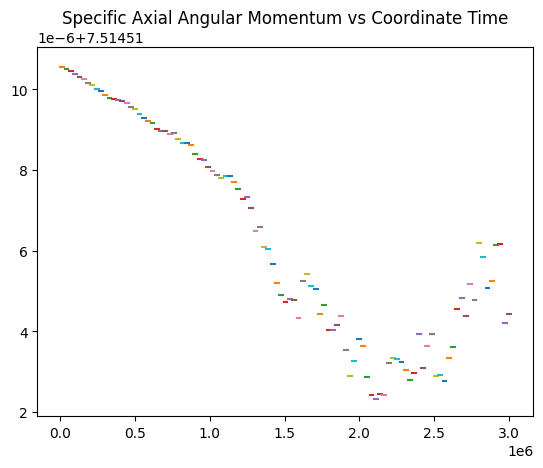

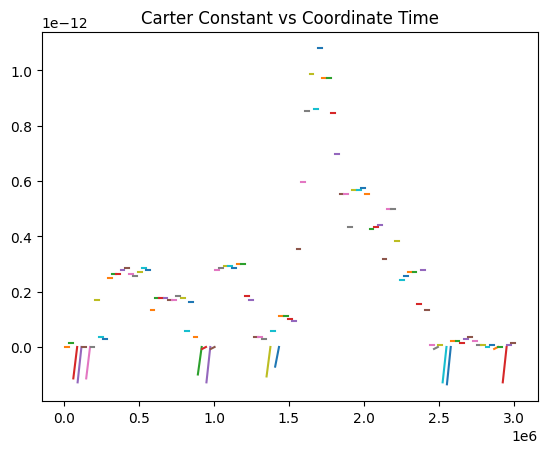

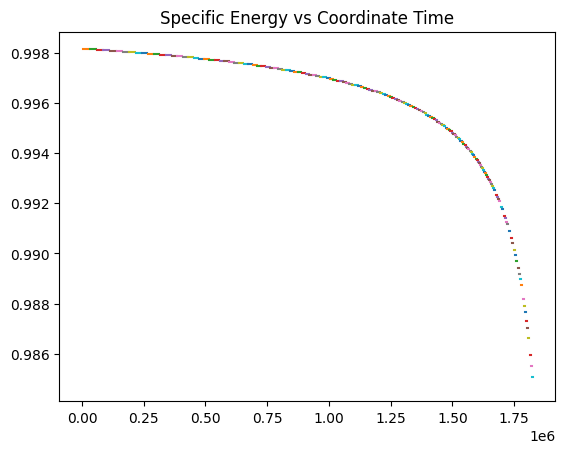

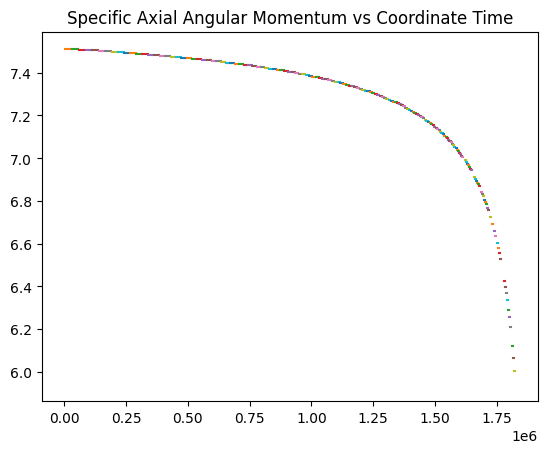

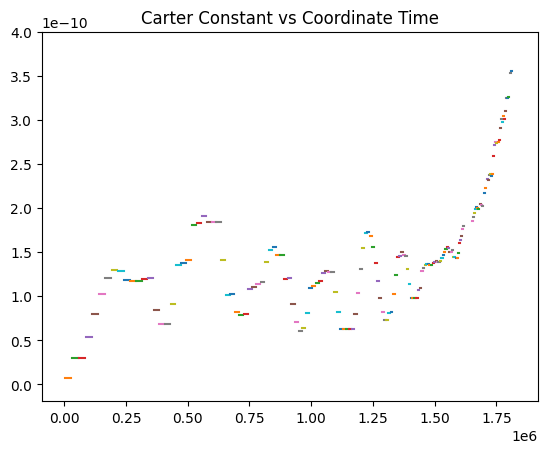

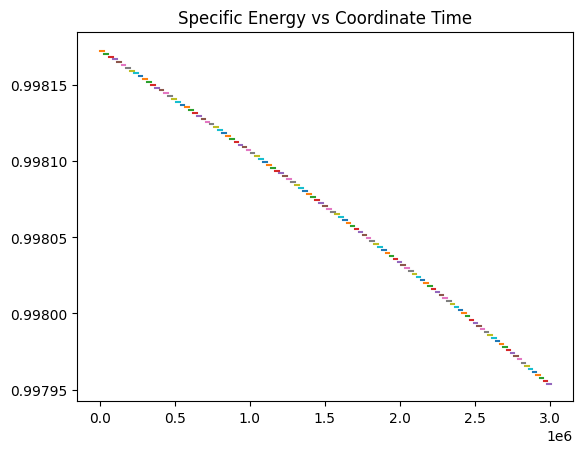

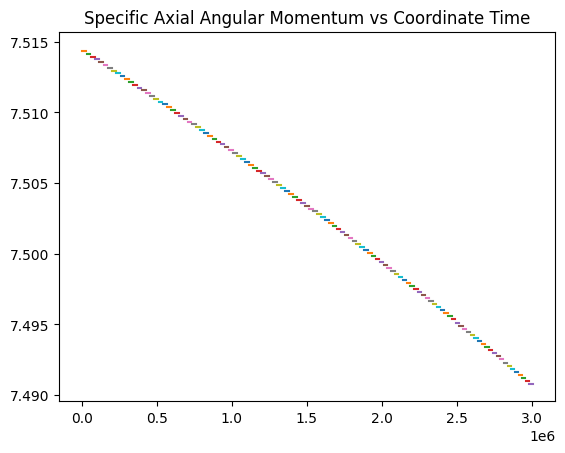

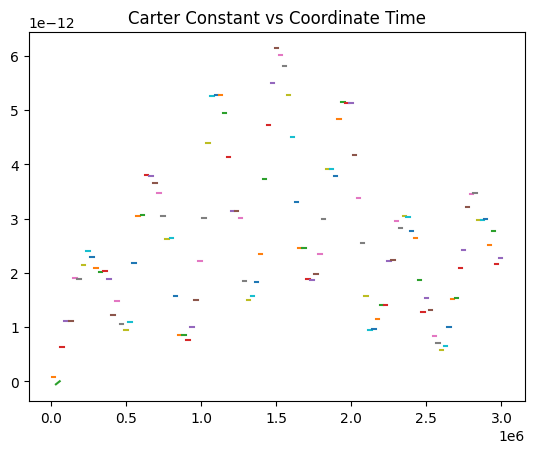

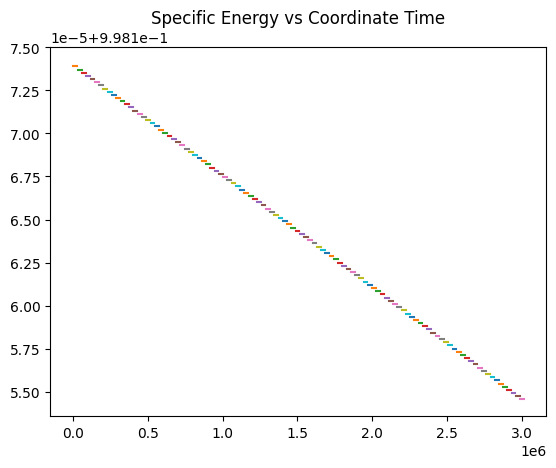

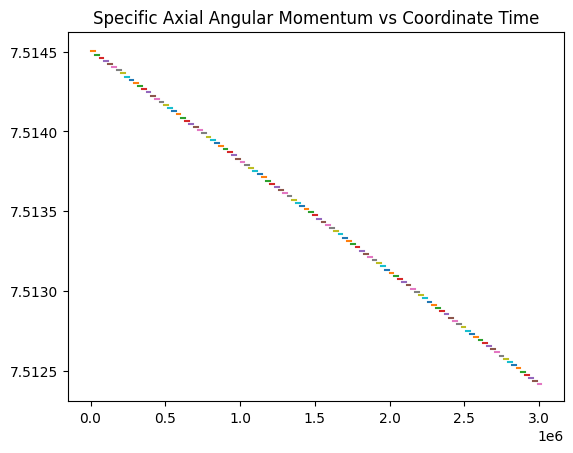

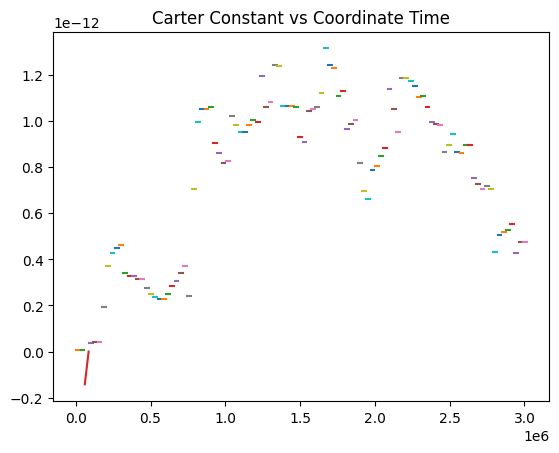

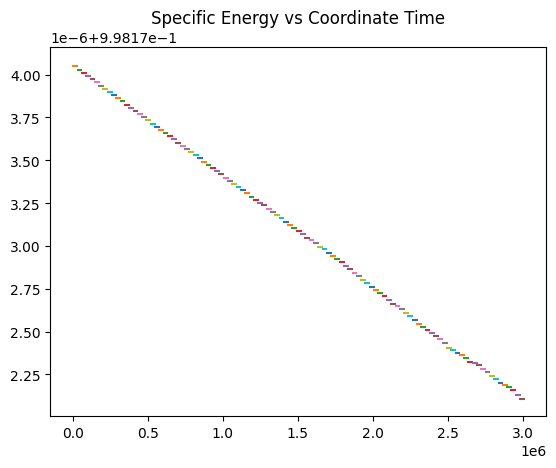

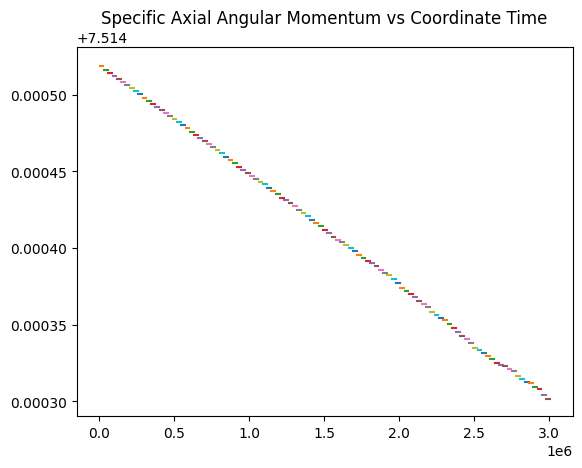

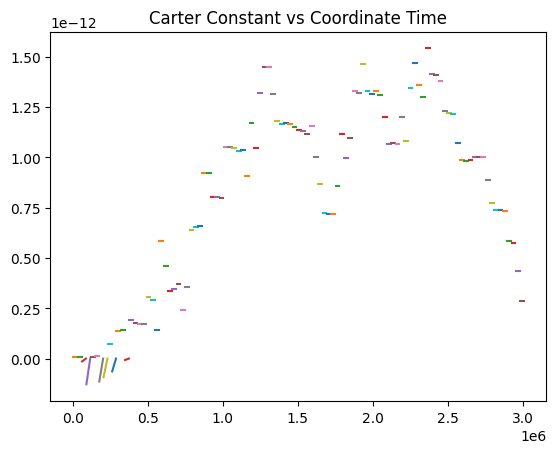

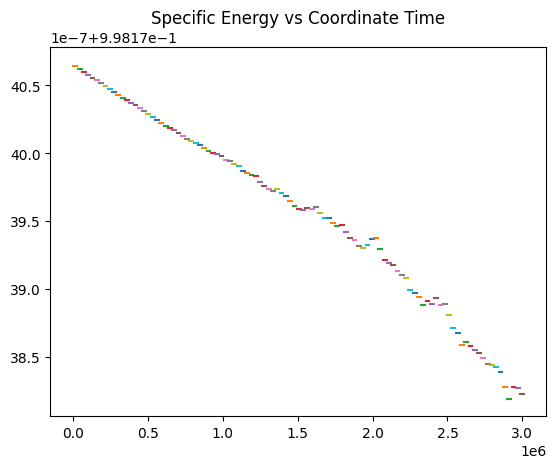

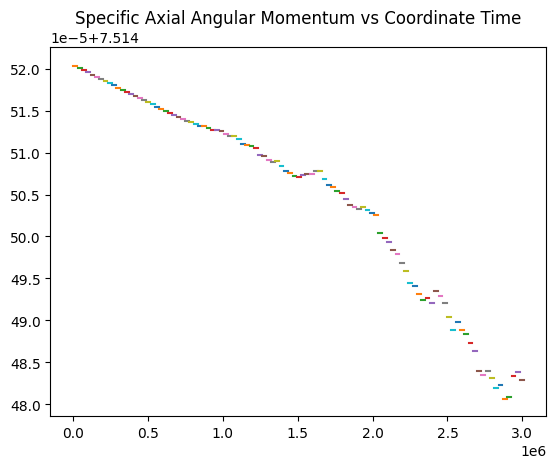

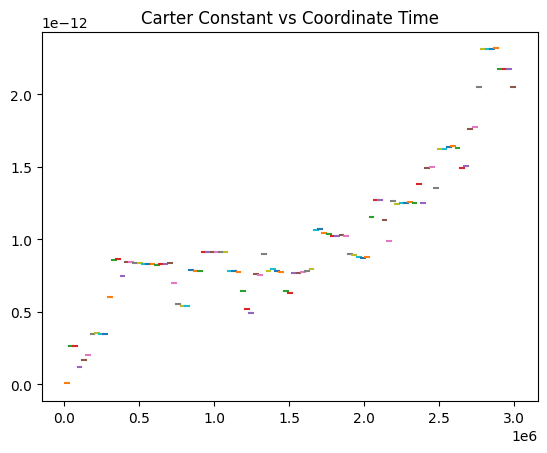

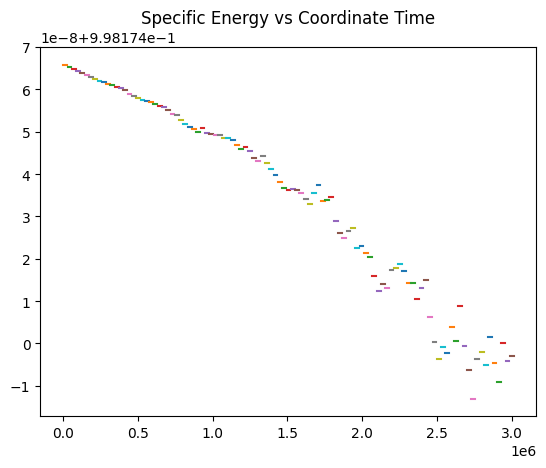

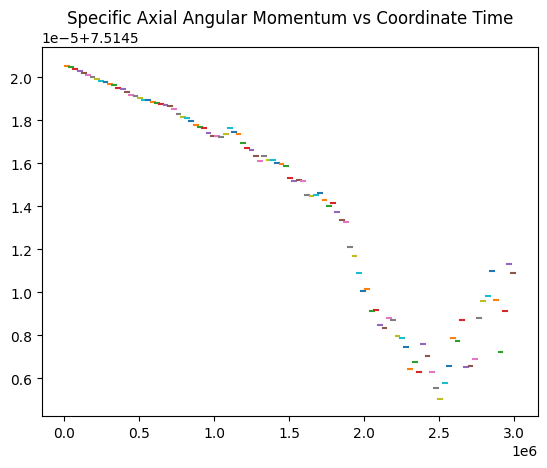

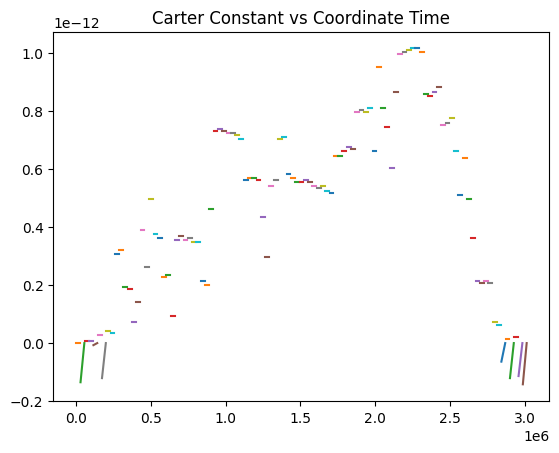

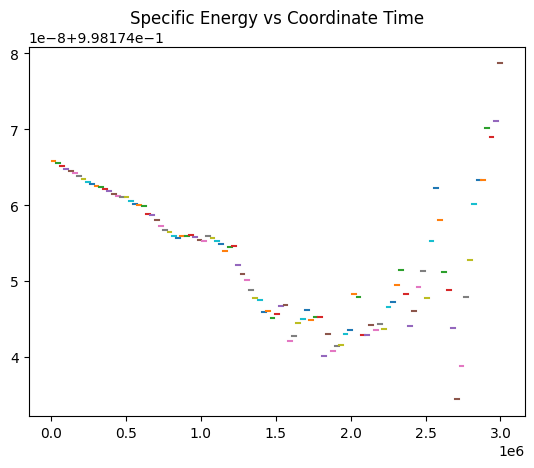

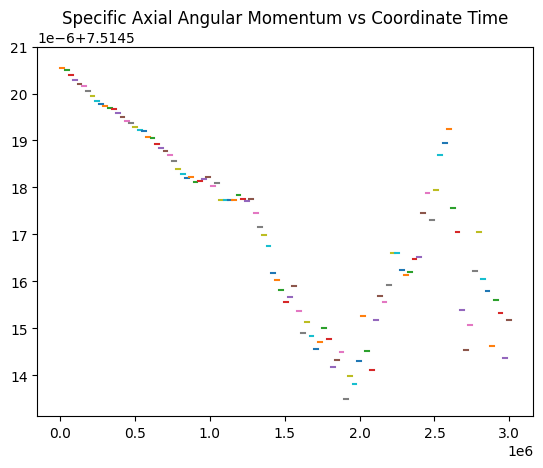

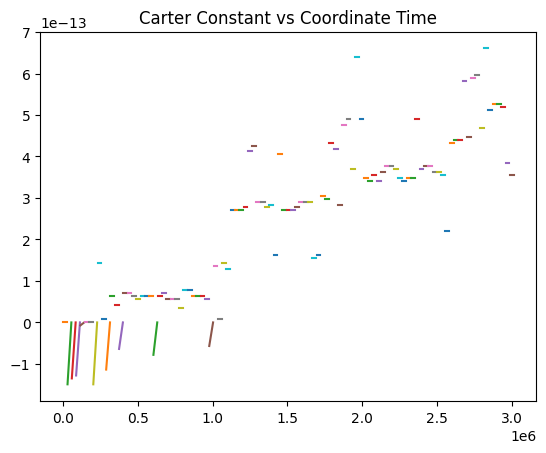

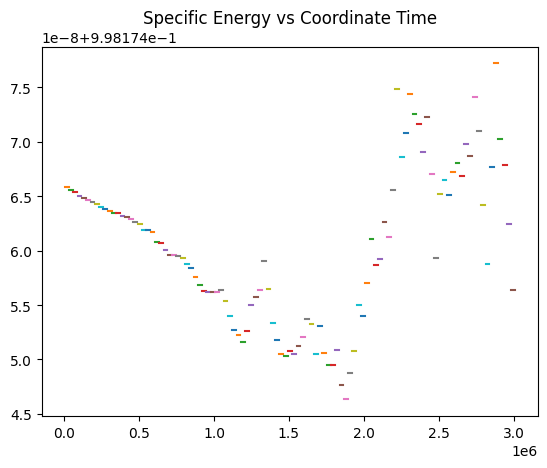

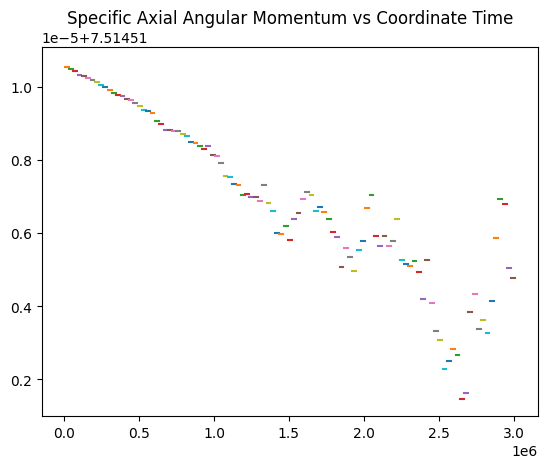

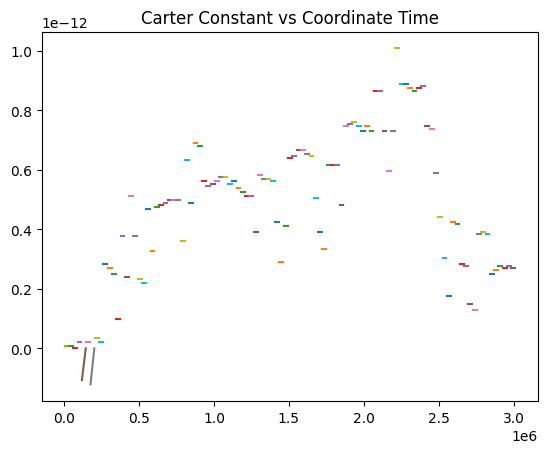

In [395]:
#print(master_dict.keys())
#master_dict[-2, True]
#op.plotvalue3(master_dict[(-2, True)][-1], "time", "radius", end=2.4e6)
#op.plotvalue3(master_dict[(-2, True)][-1], "time", "energy", end=2.4e6)
#master_dict[(-2, True)][-1]["energy"]
for stuff in master_dict.values():
    op.plotvalue3(stuff, "tracktime", "energy", linefit=False)
    op.plotvalue3(stuff, "tracktime", "L_z", linefit=False)
    op.plotvalue3(stuff, "tracktime", "carter", linefit=False)

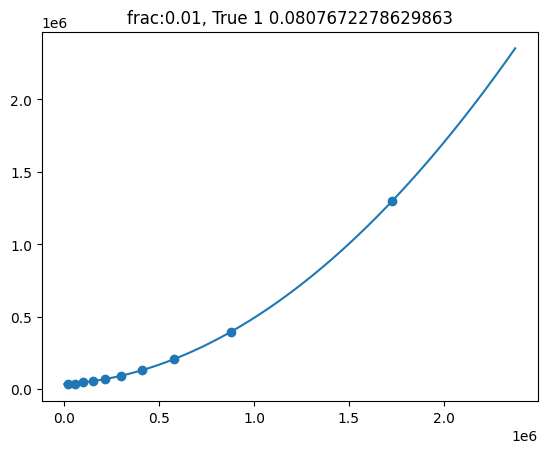

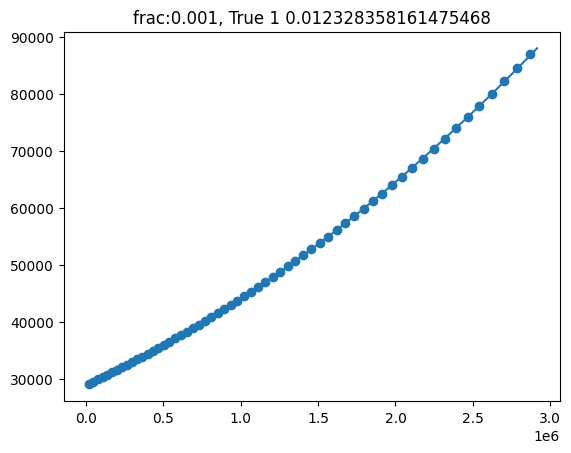

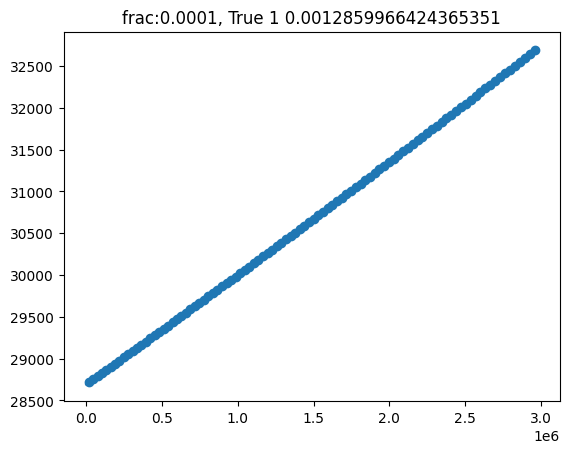

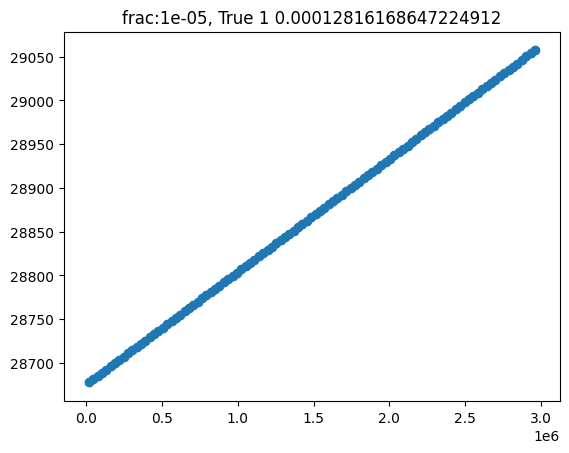

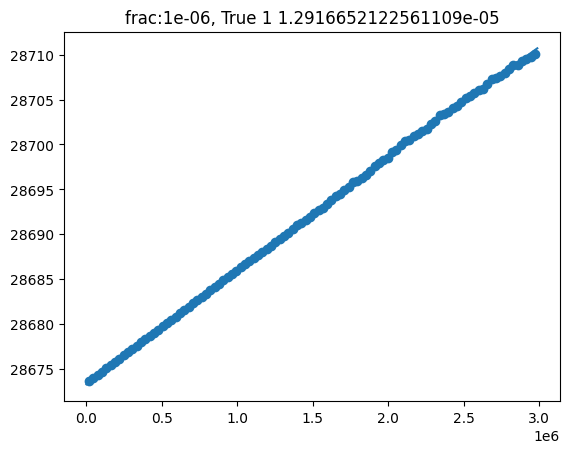

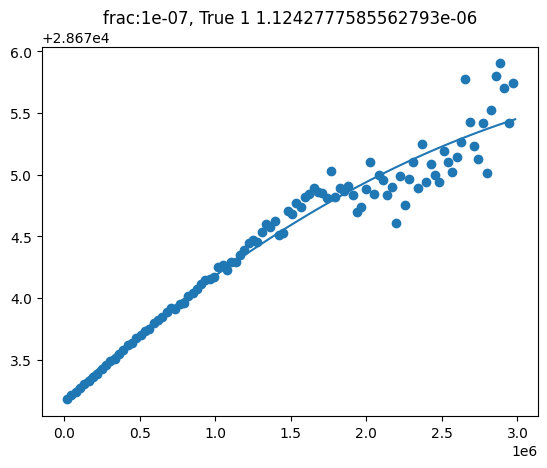

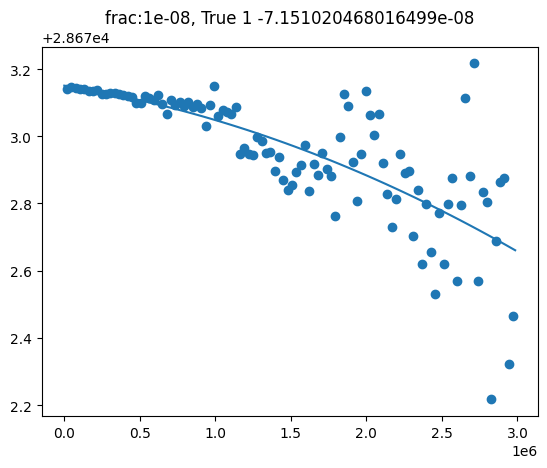

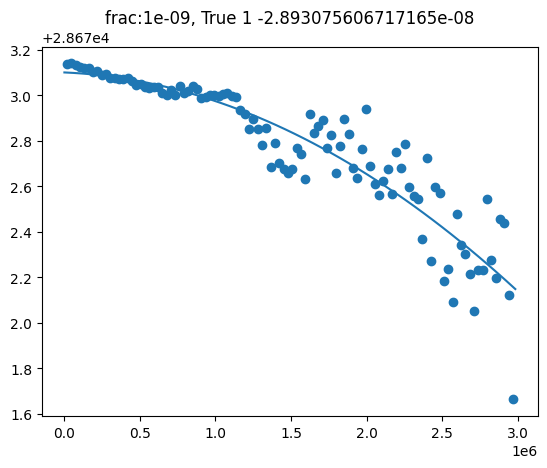

C:\Users\camcinto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\camcinto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\camcinto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


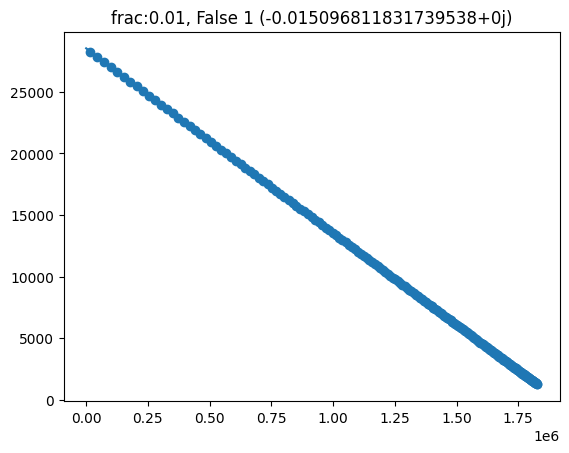

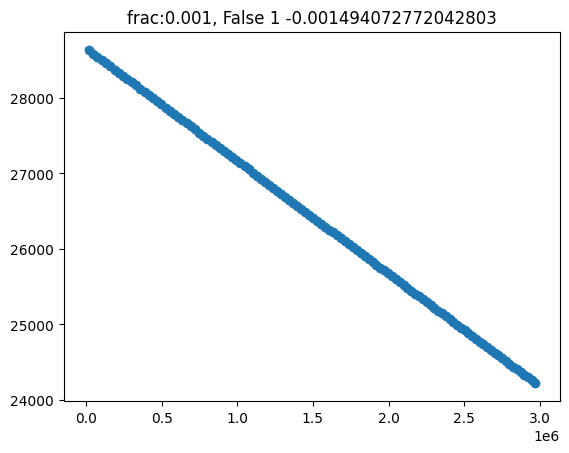

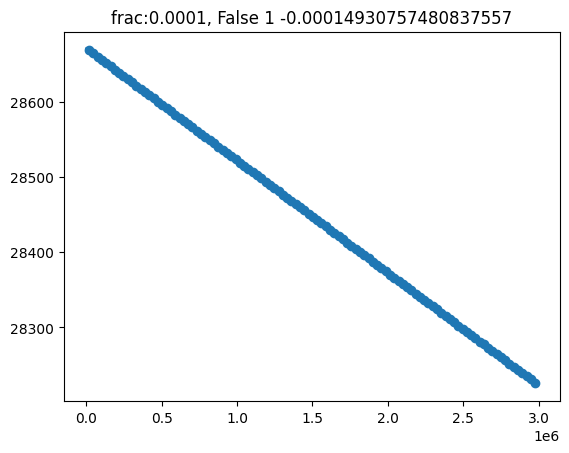

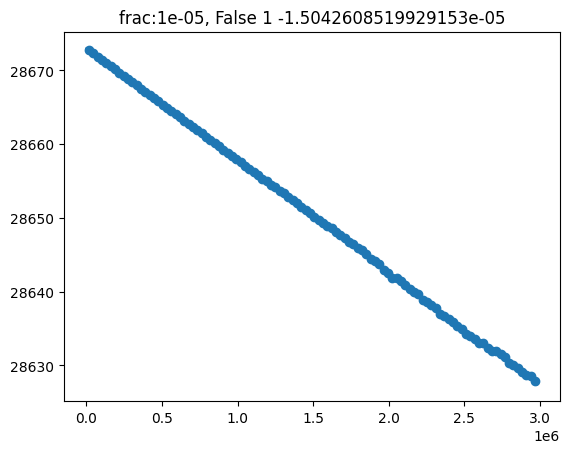

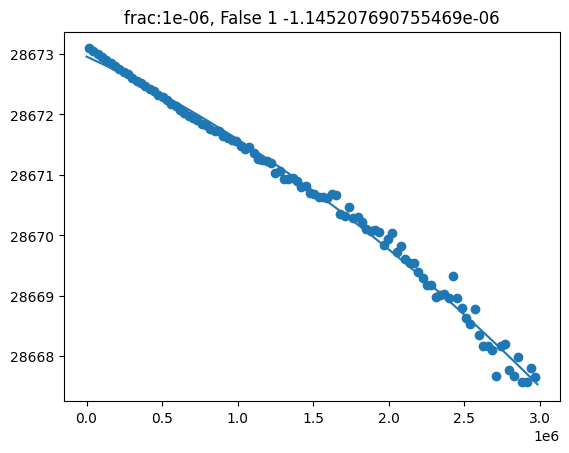

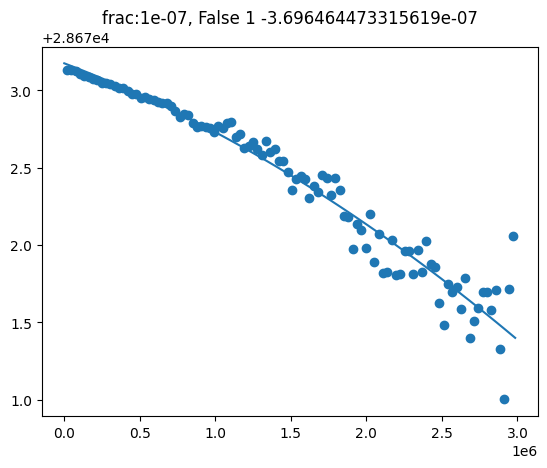

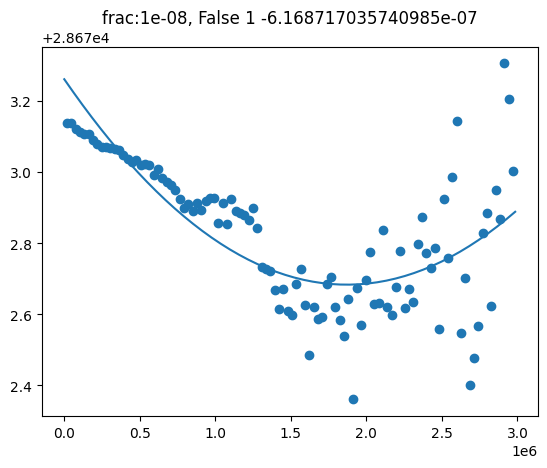

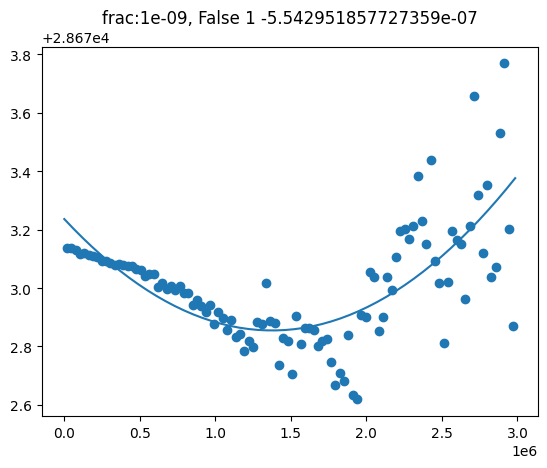

In [397]:
for stuff in master_dict.values():
    vals = np.array([thing["tracktime"][0] for thing in stuff[1:]])
    p = np.polyfit(0.5*(vals[:-1] + vals[1:]), np.diff(vals), 2)
    plt.plot(np.linspace(0, max(vals)), np.polyval(p, np.linspace(0, max(vals))))
    plt.scatter(0.5*(vals[:-1] + vals[1:]), np.diff(vals))
    plt.title(f"{stuff[1]["name"]} {p[1]}")
    plt.show()

Normalizing initial state


10011757.401959006it [00:00, 62352319.29it/s, Semilat: 7.7, Ecc 0.1, Peri: 7.0]                              


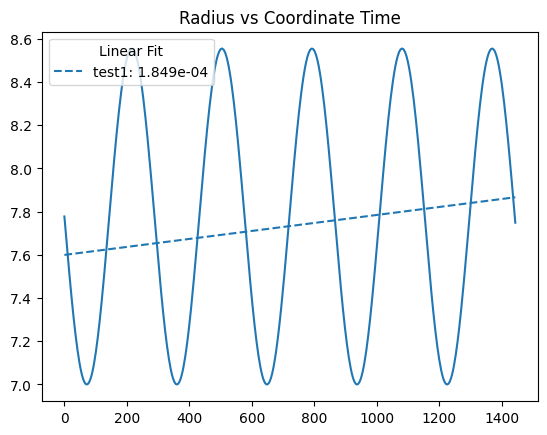

111 410


In [354]:
test1 = ml.EMRIGenerator(0.0, 1e-7, endflag=f"rad_orbit >= 5", params=[7/(1 - 0.1), 0.1, np.pi/2], label=f"test1", trigger=2, err_target=1e-10)
op.plotvalue3(test1, "time", "radius")
ix = op.get_index(test1["raw"][:,1], 0)
print(ix, len(test1["time"]))

In [280]:
ix = op.get_index(test1["raw"][:,1], 0)
print(ix, len(test1["time"]))
print(test1["raw"][ix])
ix = len(test1["time"]) - op.get_index(test1["raw"][::-1,1], 0)
print(ix, len(test1["time"]))
print(test1["raw"][ix])
ix = test1["trackix"][-2] + op.get_index(test1["raw"][test1["trackix"][-2]:,1], 0)
print(ix, len(test1["time"]))
print(test1["raw"][ix])

111 410
[ 3.60140915e+02  7.00000019e+00  1.57079633e+00  1.70954663e+01
  1.32709984e+00 -1.69882511e-05 -1.44471966e-13  7.25618256e-02]
112 410
[ 3.64256909e+02  7.00308489e+00  1.57079633e+00  1.73204640e+01
  1.32686606e+00  2.00454653e-03 -1.28282829e-13  7.24979160e-02]
350 410
[1.22581124e+03 7.00004178e+00 1.57079633e+00 5.73446392e+01
 1.32709669e+00 2.33642539e-04 2.73483758e-13 7.25609633e-02]


Do this completely unrelated thing really quick to try and get frequency

c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3874: RuntimeWarning: invalid value encountered in sqrt
  denom = (r**2) * np.sqrt(r**3*(r - 3) - 2*a*(a*C - p*sqrt_Y))


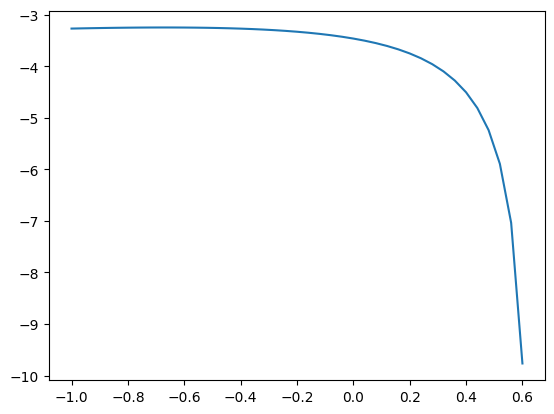

In [380]:
import MetricMathStreamline as mm
import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
importlib.reload(mm)
a_s = np.linspace(-1, 1, 51)
L_s = [mm.circL_C(mm.find_rms(a), a, 0.0, -1) for a in a_s]
r_s = [mm.find_rms(a) for a in a_s]
plt.plot(a_s, L_s)

c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3961: RuntimeWarning: invalid value encountered in sqrt
  sqrt_Y = np.sqrt(Y)
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3965: RuntimeWarning: divide by zero encountered in divide
  E = numerE / denom
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3967: RuntimeWarning: divide by zero encountered in divide
  L = numerL / denom
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3702: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  Pk = integrate.quad(lambda p: 1/((1-(zm*np.sin(p))**2)*np.sqrt(1 - k*(np.sin(p)**2))), 0, np.pi/2)[0]


borf 393.5567436218262


C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_33056\3596551842.py:102: RuntimeWarning: divide by zero encountered in scalar divide
  E, L, C = mm.schmidtparam3(pmesh1[i,j]/(1 - emesh1[i,j]**2), emesh1[i, j], inc, a)
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:444: RuntimeWarning: invalid value encountered in scalar multiply
  p = r0*(1 - (e**2))  #p is semi-latus rectum
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:488: RuntimeWarning: invalid value encountered in multiply
  eq1 = sp.Eq(f1*(x**2) - 2*g1*x*y - h1*(y**2), d1)
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:489: RuntimeWarning: invalid value encountered in multiply
  eq2 = sp.Eq(f2*(x**2) - 2*g2*x*y - h2*(y**2), d2)
C:\Users\camcinto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\_core\fromnumeric.py:3

All-NaN slice encountered
nan nan
borf 15.883097887039185


c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:4147: RuntimeWarning: All-NaN slice encountered
  Emins, Emins_ix = np.nanmin(getEs, axis=1), np.nanargmin(getEs, axis=1)


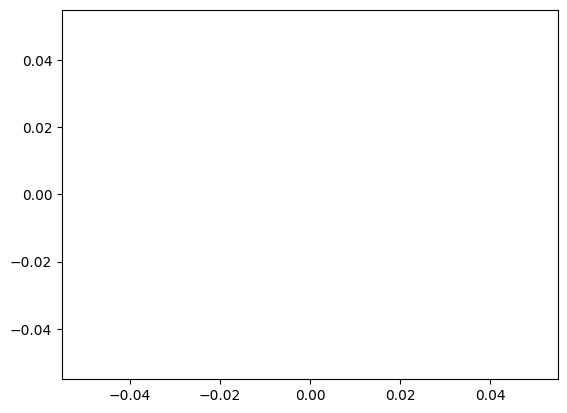

In [28]:
import MetricMathStreamline as mm
import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
importlib.reload(mm)
'''
E, L, C = mm.schmidtparam3(10, 0.1, np.pi/2, 0.0)
mm.freqs_finder(0.98, 3.0, 0.0, 0.0)
n = 100
x = np.geomspace(1, 2, n) - 1
#x = (e**x - 1)/(e-1)
y = np.geomspace(1, 2, n) - 1
xx, yy = np.meshgrid(x, y)

Ebounds = [0.96, 0.995]
Lbounds = [4, 10.2]
Emesh = np.diff(Ebounds)[0]*xx + Ebounds[0]
Lmesh = (x*(np.diff(Lbounds)[0] - 0.5) + 0.5)*yy + Lbounds[0]
#Lmesh = e

#Es = np.geomspace(0.96, 1.0, 100)
#Ls = np.geomspace(4.14, 20, 100)
#Emesh, Lmesh = np.meshgrid(Es, Ls)
a = -0.9
vals = np.zeros((len(x), len(y), 3))
gorf = False
start = time.time()
for i in range(len(y)):
    if gorf == True:
        break
    for j in range(len(x)):
        if gorf == True:
            break
        #yprint(Es[j], Ls[i])
        try:
            if mm.is_in_ELC_region2(Emesh[i, j], Lmesh[i, j], 0.0, a):
                vals[i,j] = mm.freqs_finder(Emesh[i, j], Lmesh[i, j], 0.0, a)
            else:
                vals[i,j] = [np.nan, np.nan, np.nan]
        except Exception as e:
            print(e)
            E1, L1, E2, L2 = mm.get_EL_curve(a, 0.0)
            plt.plot(E1, L1)
            plt.plot(E2, L2)
            gorf = True
print("borf", time.time() - start)
'''
n = 100
Es1 = np.linspace(0.954, 1.0, n)
Ls1 = np.linspace(4.14, 20, n)
Es1 = np.geomspace(0.954, 0.995, n)
Ls1 = np.geomspace(1, 11, n//2) - 1
Ls1 = np.unique(np.concatenate((Ls1, -Ls1)))

Emesh1, Lmesh1 = np.meshgrid(Es1, Ls1)
'''x = np.geomspace(1, 2, n) - 1
x = (np.e**x - 1)/(np.e-1)
y = np.geomspace(1, 2, n) - 1
xx, yy = np.meshgrid(x, y)


Ebounds = [0.96, 0.995]
Lbounds = [4, 10.2]'''
#Emesh1 = np.diff(Ebounds)[0]*xx + Ebounds[0]
#Lmesh1 = (x*(np.diff(Lbounds)[0] - 0.5) + 0.5)*yy + Lbounds[0]
a, C = 0.9, 14
vals1 = np.zeros((*np.shape(Emesh1), 3))
gorf = False
start = time.time()
for i in range(len(vals1)):
    if gorf == True:
        break
    for j in range(len(vals1[0])):
        if gorf == True:
            break
        #print(Emesh1[i, j], Lmesh1[i, j])
        try:
            if mm.is_in_ELC_region3(Emesh1[i, j], Lmesh1[i, j], C, a):
                vals1[i,j] = mm.freqs_finder(Emesh1[i, j], Lmesh1[i, j], C, a)
            else:
                vals1[i,j] = [np.nan, np.nan, np.nan]
        except Exception as e:
            print(e)
            print(Emesh1[i, j], Lmesh1[i, j])
            E1, L1, E2, L2 = mm.get_EL_curve(a, C)
            plt.plot(E1, L1)
            plt.plot(E2, L2)
            gorf = True
print("borf", time.time() - start)
###
n = 100
a, inc = 0.9, np.pi/2
es1 = np.geomspace(1, 2, n) - 1
ps1 = np.geomspace(mm.find_rmb(a)*2, mm.find_rmb(a)*20, n)

emesh1, pmesh1 = np.meshgrid(es1, ps1) 
Emesh2, Lmesh2, Cmesh2 = np.ones_like(emesh1), np.ones_like(emesh1), np.ones_like(emesh1)
for i in range(len(emesh1)):
    for j in range(len(emesh1[0])):
        try:
            E, L, C = mm.schmidtparam3(pmesh1[i,j]/(1 - emesh1[i,j]**2), emesh1[i, j], inc, a)
            Emesh2[i,j], Lmesh2[i,j], Cmesh2[i,j] = E, L, C
        except:
            Emesh2[i,j], Lmesh2[i,j], Cmesh2[i,j] = np.nan, np.nan, np.nan

'''x = np.geomspace(1, 2, n) - 1
x = (np.e**x - 1)/(np.e-1)
y = np.geomspace(1, 2, n) - 1
xx, yy = np.meshgrid(x, y)


Ebounds = [0.96, 0.995]
Lbounds = [4, 10.2]'''
#Emesh1 = np.diff(Ebounds)[0]*xx + Ebounds[0]
#Lmesh1 = (x*(np.diff(Lbounds)[0] - 0.5) + 0.5)*yy + Lbounds[0]
vals2 = np.zeros((*np.shape(emesh1), 3))
gorf = False
start = time.time()
for i in range(len(vals2)):
    if gorf == True:
        break
    for j in range(len(vals2[0])):
        if gorf == True:
            break
        #print(Emesh1[i, j], Lmesh1[i, j])
        try:
            if mm.is_in_ELC_region3(Emesh2[i, j], Lmesh2[i, j], Cmesh2[i, j], a):
                vals2[i,j] = mm.freqs_finder(Emesh2[i, j], Lmesh2[i, j], Cmesh2[i, j], a)
            else:
                vals2[i,j] = [np.nan, np.nan, np.nan]
        except Exception as e:
            print(e)
            print(Emesh2[i, j], Lmesh2[i, j])
            E1, L1, E2, L2 = mm.get_EL_curve(a, Cmesh2[i, j])
            plt.plot(E1, L1)
            plt.plot(E2, L2)
            gorf = True
print("borf", time.time() - start)

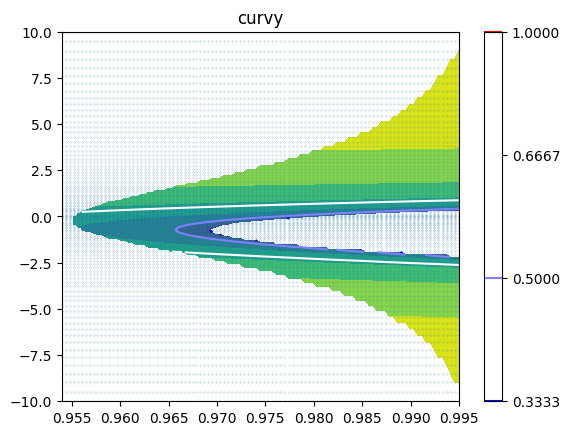

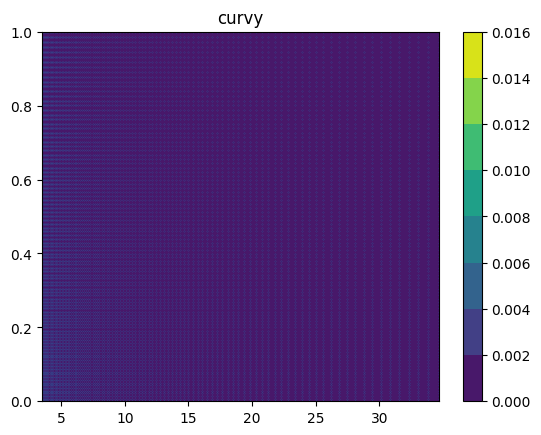

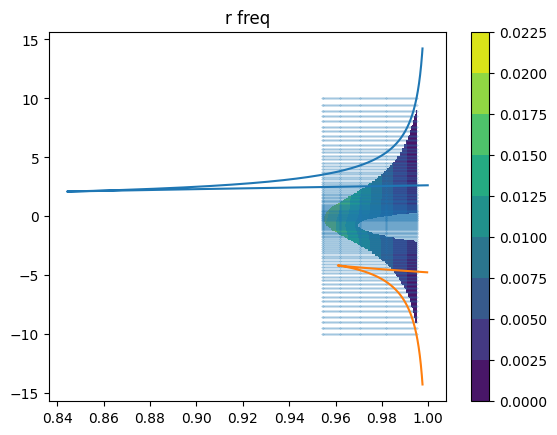

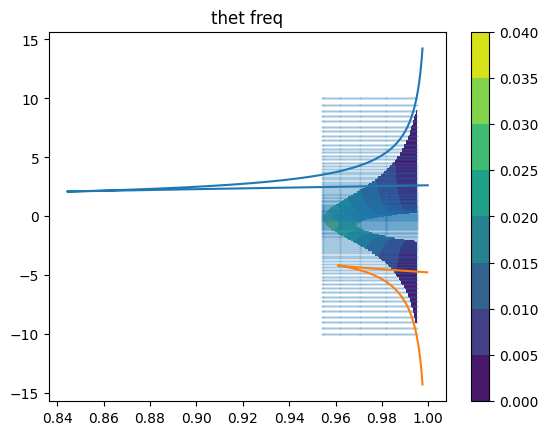

(99, 100) (99, 100) (99, 100)


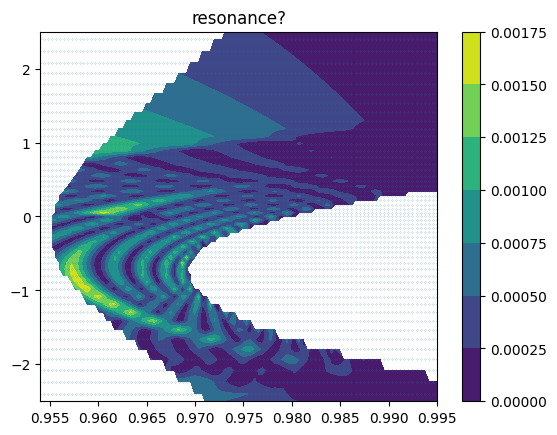

ValueError: shape-mismatch for sum

In [31]:
import MetricMathStreamline as mm
import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
importlib.reload(mm)
E1, L1, E2, L2 = mm.get_EL_curve(a, C, 200)
'''
#plt.scatter(Es, Ls, c=vals[:, :, 0])
h = plt.contourf(Emesh, Lmesh, vals[:,:, 0]/vals[:,:, 2], levels=rats)
#plt.axis('scaled')
plt.colorbar()
xa, xb = plt.xlim()
ya, yb = plt.ylim()
plt.scatter(Emesh, Lmesh, s=0.02)

#print(L1)
plt.plot(E1, L1)
#plt.scatter(E1, L1)
#plt.plot(E2, L2)
#plt.xlim(xa, xb)
#plt.ylim(ya, yb)
#plt.xlim(0.96, 0.98)
#plt.ylim(4, 5.5)
plt.show()
'''


vals1 = np.abs(vals1)
#plt.scatter(Es, Ls, c=vals[:, :, 0])
#h = plt.contourf(Emesh1, Lmesh1, np.minimum(np.ones_like(vals1[:,:,0]), vals1[:,:,0]/vals1[:,:, 1]))
h = plt.contourf(Emesh1, Lmesh1, np.minimum(1.01*np.ones_like(vals1[:,:,0]), vals1[:,:,0]/vals1[:,:, 1]))
#plt.colorbar()
j = plt.contour(Emesh1, Lmesh1, np.minimum(1.01*np.ones_like(vals1[:,:,0]), vals1[:,:,0]/vals1[:,:, 1]), cmap="bwr", levels=[1/3, 1/2, 2/3, 1.0])
plt.colorbar()
plt.title("curvy")
#plt.axis('scaled')

xa, xb = plt.xlim()
ya, yb = plt.ylim()
plt.scatter(Emesh1, Lmesh1, s=0.02)
#plt.plot(E1, L1)
#plt.plot(E2, L2)
#plt.xlim(xa, xb)
#plt.ylim(ya, yb)
#plt.xlim(0.96, 0.98)
#plt.ylim(-2.5, 2.5)
plt.show()

vals1 = np.abs(vals1)
#plt.scatter(Es, Ls, c=vals[:, :, 0])
#h = plt.contourf(Emesh1, Lmesh1, np.minimum(np.ones_like(vals1[:,:,0]), vals1[:,:,0]/vals1[:,:, 1]))
h = plt.contourf(pmesh1, emesh1, vals2[:,:,0])#np.minimum(1.01*np.ones_like(vals2[:,:,0]), vals2[:,:,0]/vals2[:,:, 1]))
#plt.colorbar()
#j = plt.contour(Emesh1, Lmesh1, np.minimum(1.01*np.ones_like(vals1[:,:,0]), vals1[:,:,0]/vals1[:,:, 1]), cmap="bwr", levels=[1/3, 1/2, 2/3, 1.0])
plt.colorbar()
plt.title("curvy")
#plt.axis('scaled')

xa, xb = plt.xlim()
ya, yb = plt.ylim()
plt.scatter(pmesh1, emesh1, s=0.02)
#plt.plot(E1, L1)
#plt.plot(E2, L2)
#plt.xlim(xa, xb)
#plt.ylim(ya, yb)
#plt.xlim(0.96, 0.98)
#plt.ylim(-2.5, 2.5)
plt.show()

h = plt.contourf(Emesh1, Lmesh1, vals1[:,:, 0])
plt.colorbar()
#plt.contour(h, colors="k", levels=[1/2, 1/3, 1/4, 1/5, 2/3, 2/5, 3/4, 3/5, 4/5])
plt.title("r freq")
#plt.axis('scaled')
xa, xb = plt.xlim()
ya, yb = plt.ylim()
plt.scatter(Emesh1, Lmesh1, s=0.02)
plt.plot(E1, L1)
plt.plot(E2, L2)
#plt.xlim(xa, xb)
#plt.ylim(ya, yb)
#plt.xlim(0.96, 0.98)
#plt.ylim(-2.5, 2.5)
plt.show()

h = plt.contourf(Emesh1, Lmesh1, vals1[:,:, 1])
plt.colorbar()
#plt.contour(h, colors="k", levels=[1/2, 1/3, 1/4, 1/5, 2/3, 2/5, 3/4, 3/5, 4/5])
plt.title("thet freq")
#plt.axis('scaled')
xa, xb = plt.xlim()
ya, yb = plt.ylim()
plt.scatter(Emesh1, Lmesh1, s=0.02)
plt.plot(E1, L1)
plt.plot(E2, L2)
#plt.xlim(xa, xb)
#plt.ylim(ya, yb)
#plt.xlim(0.96, 0.98)
#plt.ylim(-2.5, 2.5)
plt.show()

#plt.scatter(Es, Ls, c=vals[:, :, 0])
#h = plt.contourf(Emesh1, Lmesh1, np.minimum(np.ones_like(vals1[:,:,0]), vals1[:,:,0]/vals1[:,:, 1]))
ints = np.arange(-3, 4)
n, k, m = np.meshgrid(ints, ints, ints, indexing='ij')
combos = np.stack([n, k, m], axis=-1).reshape(-1, 3)

# Remove the trivial (0,0,0)
combos = combos[np.any(combos != 0, axis=1)]  # shape (342, 3)

# Compute resonance expression: n*w_r + k*w_t + m*w_p
# Broadcasting:
# freqs: (100,100,3)
# combos.T: (3,342)
# result: (100,100,342)
res_values = np.abs(np.tensordot(vals1, combos.T, axes=([2],[0])))
# Get the smallest absolute value (closest to resonance)
closest = res_values.min(axis=-1)
print(np.shape(Emesh1), np.shape(Lmesh1), np.shape(closest))
h = plt.contourf(Emesh1, Lmesh1, closest)
#plt.colorbar()
plt.colorbar()
plt.title("resonance?")
#plt.axis('scaled')

xa, xb = plt.xlim()
ya, yb = plt.ylim()
plt.scatter(Emesh1, Lmesh1, s=0.02)
#plt.plot(E1, L1)
#plt.plot(E2, L2)
#plt.xlim(xa, xb)
#plt.ylim(ya, yb)
#plt.xlim(0.96, 0.98)
plt.ylim(-2.5, 2.5)
plt.show()

#plt.scatter(Es, Ls, c=vals[:, :, 0])
#h = plt.contourf(Emesh1, Lmesh1, np.minimum(np.ones_like(vals1[:,:,0]), vals1[:,:,0]/vals1[:,:, 1]))
ints = np.arange(-3, 4)
n, k = np.meshgrid(ints, ints, indexing='ij')
combos = np.stack([n, k], axis=-1).reshape(-1, 2)

# Remove the trivial (0,0)
combos = combos[np.any(combos != 0, axis=1)]  # shape (342, 2)

# Compute resonance expression: n*w_r + k*w_t + m*w_p
# Broadcasting:
# freqs: (100,100,3)
# combos.T: (3,342)
# result: (100,100,342)
res_values = np.abs(np.tensordot(vals1, combos.T, axes=([2],[0])))
# Get the smallest absolute value (closest to resonance)
closest = res_values.min(axis=-1)
print(np.shape(Emesh1), np.shape(Lmesh1), np.shape(closest))
h = plt.contourf(Emesh1, Lmesh1, closest)
#plt.colorbar()
plt.colorbar()
plt.title("rtheta resonance?")
#plt.axis('scaled')

xa, xb = plt.xlim()
ya, yb = plt.ylim()
plt.scatter(Emesh1, Lmesh1, s=0.02)
#plt.plot(E1, L1)
#plt.plot(E2, L2)
#plt.xlim(xa, xb)
#plt.ylim(ya, yb)
#plt.xlim(0.96, 0.98)
plt.ylim(-2.5, 2.5)
plt.show()


plt.figure(figsize=(7,6))
im = plt.imshow(np.log10(closest + 1e-12), origin='lower', cmap='viridis')
plt.colorbar(im, label='log10(|n·w_r + k·w_t + m·w_p|)')
plt.title("Resonance Closeness Map")
plt.xlabel("Index M")
plt.ylabel("Index N")
plt.show()

def resonance_closeness_with_labels(freqs, nmax=3):
    vals = np.arange(-nmax, nmax + 1)
    n, k, m = np.meshgrid(vals, vals, vals, indexing='ij')
    combos = np.stack([n, k, m], axis=-1).reshape(-1, 3)
    combos = combos[np.any(combos != 0, axis=1)]

    res_values = np.abs(np.tensordot(freqs, combos.T, axes=([2],[0])))
    idx_min = np.argmin(res_values, axis=-1)
    closest = res_values[np.arange(res_values.shape[0])[:,None],
                         np.arange(res_values.shape[1])[None,:],
                         idx_min]
    nkmlabels = combos[idx_min]  # shape (N,M,3)
    return closest, nkmlabels

closest, labels = resonance_closeness_with_labels(vals1)

# Identify where random nkm values dominate
rn, rk, rm = np.random.choice(ints, 3)
mask = (labels[...,0]==rn) & (labels[...,1]==rk) & (labels[...,2]==rm)

plt.figure(figsize=(7,6))
plt.imshow(mask, origin='lower', cmap='Reds')
plt.title(f"Dominant (n,k,m) = ({rn}, {rk}, {rm}) Resonance")
plt.show()

plt.figure(figsize=(7,6))
im = plt.imshow(np.log10(closest + 1e-12), origin='lower', cmap='viridis')
plt.contour(mask, levels=[0.5], colors='red', linewidths=1)
plt.colorbar(im, label='log10(|resonance|)')
plt.show()



In [23]:
importlib.reload(mm)
print(np.shape((Emesh1**2 - 1.0)))
print(np.shape(2.0*np.ones_like(Emesh1)))
print(np.shape(((a**2)*(Emesh1**2 - 1.0) - Lmesh1**2 - C)))
print(np.shape((2*((Lmesh1 - a*Emesh1)**2) + 2*C)))
print(np.shape(-(a**2)*C*np.ones_like(Emesh1)))
pmesh1 = np.ones_like(Emesh1)
emesh1 = np.ones_like(Emesh1)
imesh1 = np.ones_like(Emesh1)
for i in range(len(Emesh1)):
    for j in range(len(Emesh1[0])):
        turns, flats, zs = mm.root_getter(Emesh1[i, j], Lmesh1[i, j], C, a)
        p, e, inc = 2*turns[-1]*turns[-2]/(turns[-1] + turns[-2]), (turns[-1] - turns[-2])/(turns[-1] + turns[-2]), np.arccos(min(1.0, np.mean(np.abs(zs[1:3]))))
        pmesh1[i, j] = p
        emesh1[i, j] = e
        imesh1[i, j] = inc


(99, 100)
(99, 100)
(99, 100)
(99, 100)
(99, 100)


C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_33056\2057874642.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  pmesh1[i, j] = p
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_33056\2057874642.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  emesh1[i, j] = e
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_33056\2057874642.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  pmesh1[i, j] = p
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_33056\2057874642.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  emesh1[i, j] = e
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_33056\2057874642.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  pmesh1[i, j] = p
C:\Users\camcinto\AppData\Local\Temp\1\ipykernel_33056\2057874642.py:15: ComplexWarning: Casting complex values to real discards the imaginary part
  emesh1[i, j] = 

In [24]:
print(pmesh1)

[[123.06061483 122.92807118 122.79565739 ... 110.78878979 110.66822484
  110.5477771 ]
 [111.68331205 111.5611581  111.43912415 ... 100.37469122 100.26359996
  100.15261684]
 [101.40900956 101.29625426 101.18360997 ...  90.97124132  90.86871008
   90.7662787 ]
 ...
 [ 99.16313257  99.08713572  99.01119339 ...  92.03989532  91.96901793
   91.89819158]
 [109.20234581 109.11859892 109.03491248 ... 101.35436062 101.27628912
  101.19827418]
 [120.33680326 120.24441805 120.15209994 ... 111.68114442 111.59505711
  111.50903254]]


In [1031]:
import numpy as np
import matplotlib.pyplot as plt

N, M = 200, 200
r_vals = np.linspace(1, 10, N)
theta_vals = np.linspace(0, np.pi/2, M)

# Create full (N,M) grids (indexing='ij' makes first axis r, second axis theta)
r_grid, theta_grid = np.meshgrid(r_vals, theta_vals, indexing='ij')

# Now every computed freq has shape (N,M)
w_r = 1.0 / r_grid
w_t = 2.0 / r_grid
w_p = 3.0 / r_grid + 0.05 * np.sin(theta_grid)

print(w_r.shape, w_t.shape, w_p.shape)  # all (200, 200)

# Stack into freqs array (N,M,3)
freqs = np.stack([w_r, w_t, w_p], axis=-1)

# Use your existing functions (example names from earlier)
closest, labels = resonance_closeness_with_labels(freqs)  # assuming this is defined

# pick an example resonance mask
mask = (labels[...,0]==2) & (labels[...,1]==-1) & (labels[...,2]==0)
#print(sum(mask))
rn, rk, rm = np.random.choice(ints, 3)
mask = ((labels[...,0]==rn) | (labels[...,0]==-rn)) & ((labels[...,1]==rk) | (labels[...,1]==-rk)) & ((labels[...,2]==rm) | (labels[...,2]==-rm))
if sum(sum(mask)) == 0:
    print("none", rn, rk, rm)
else:
    plt.figure(figsize=(7,6))
    plt.imshow(np.log10(closest + 1e-12), origin='lower', cmap='viridis')
    plt.contour(mask, levels=[0.5], colors='red', linewidths=1)
    plt.colorbar(im, label='log10(|resonance|)')
    plt.title("Visible (2, -1, 0) Resonance Band")
    plt.title(f"Dominant (n,k,m) = ({rn}, {rk}, {rm}) Resonance")
    plt.show()
    #print(labels)


(200, 200) (200, 200) (200, 200)
none 0 3 0


[0.969]


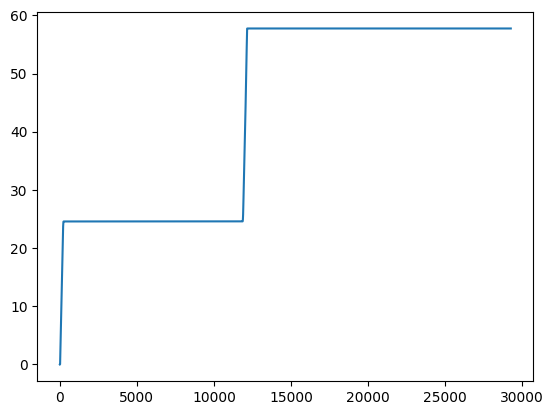

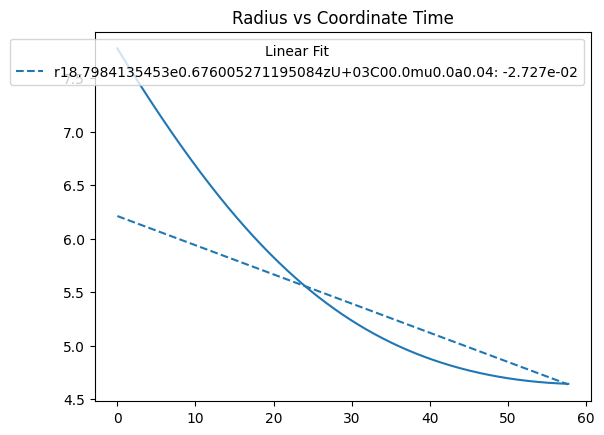

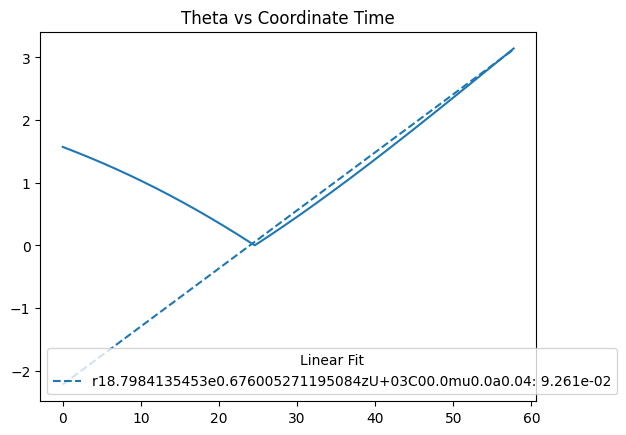

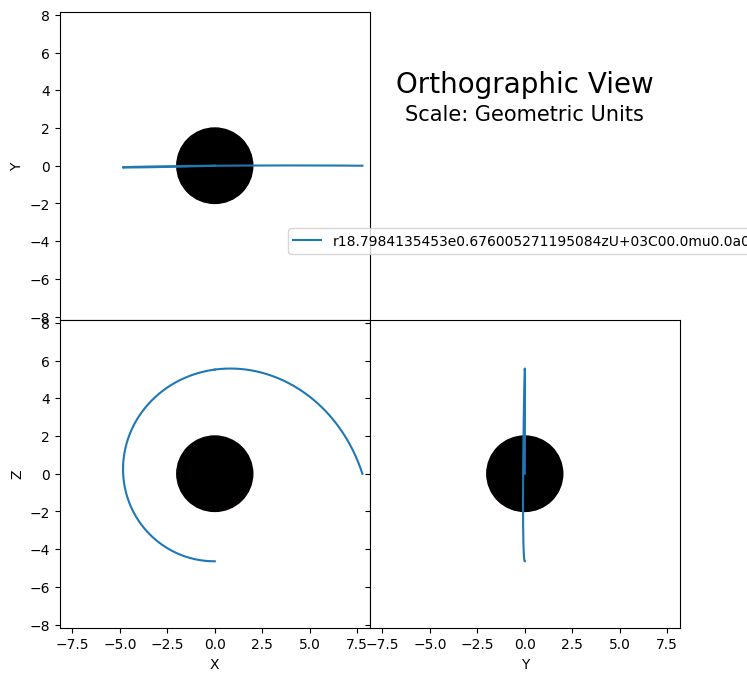

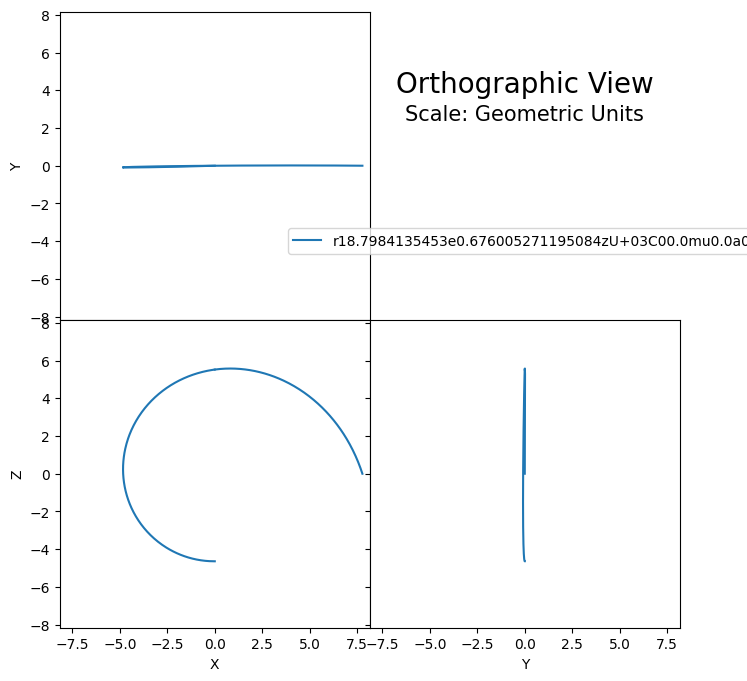

In [850]:
import MainLoopStreamline as ml
#thirp = ml.EMRIGenerator(a, 0.0, "rad_orbit > 10", cons=[0.969 , 0.0, C])

import OrbitPlotter as op
importlib.reload(op)
plt.plot(thirp["time"])
print(thirp["energy"])
op.plotvalue3(thirp, "time", "radius")
op.plotvalue3(thirp, "time", "theta")
op.orthoplots(thirp, ortho=True, cb=True)
op.orthoplots(thirp, ortho=True)

In [798]:
importlib.reload(mm)
print(C, a)
mm.is_in_ELC_region3(0.98, 0, C, a)

17 0.04


True

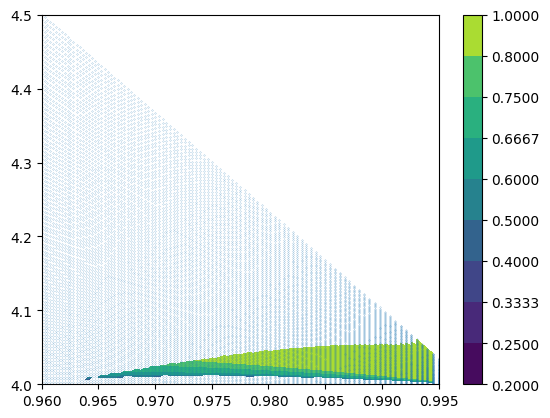

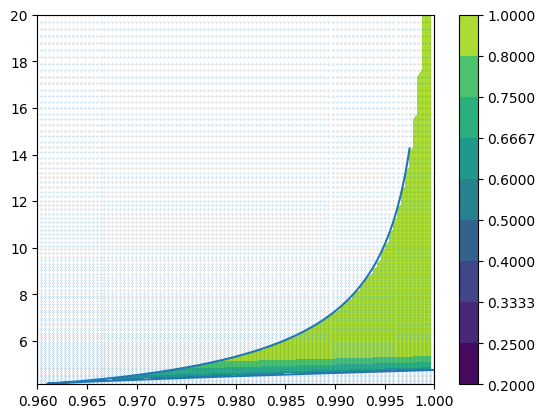

In [474]:
import MetricMathStreamline as mm
import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
importlib.reload(mm)

#plt.scatter(Es, Ls, c=vals[:, :, 0])
h = plt.contourf(Emesh, Lmesh, vals[:,:, 0]/vals[:,:, 2], levels=rats)
#plt.axis('scaled')
plt.colorbar()
xa, xb = plt.xlim()
ya, yb = plt.ylim()
plt.scatter(Emesh, Lmesh, s=0.02)
E1, L1, E2, L2 = mm.get_EL_curve(a, 0.0, 200)
plt.plot(E1, L1)
plt.scatter(E1, L1)
#plt.plot(E2, L2)
plt.xlim(xa, xb)
plt.ylim(ya, yb)
#plt.xlim(0.83, 0.97)
#plt.ylim(2, 3)
plt.show()

#plt.scatter(Es, Ls, c=vals[:, :, 0])
h = plt.contourf(Emesh1, Lmesh1, vals1[:,:, 0]/vals1[:,:, 2], levels=rats)
#plt.axis('scaled')
plt.colorbar()
xa, xb = plt.xlim()
ya, yb = plt.ylim()
plt.scatter(Emesh1, Lmesh1, s=0.02)
plt.plot(E1, L1)
#plt.plot(E2, L2)
plt.xlim(xa, xb)
plt.ylim(ya, yb)
#plt.xlim(0.83, 0.97)
#plt.ylim(2, 3)
plt.show()




In [333]:
print(mm.is_in_ELC_region(0.997, 8, 0, a, tol=1e-2))
print(mm.is_in_ELC_region(0.997, 8, 0, a, tol=1e-3))
print(mm.is_in_ELC_region(0.997, 8, 0, a, tol=1e-4))
print(mm.find_rmb(a))

[np.float64(4.587269901732017), np.float64(-31.667636732038485)]
[np.float64(31.67305027617329), np.float64(-2.5915345521075563)]
True
[np.float64(4.706442980356206), np.float64(-15.860700674963537)]
[np.float64(15.881052025453155), np.float64(-2.6201173030005793)]
True
[np.float64(4.717581310785216), np.float64(-13.202483730368995)]
[np.float64(13.217079228101397), np.float64(-2.6227323088343835)]
True
5.656809750418045


-0.9


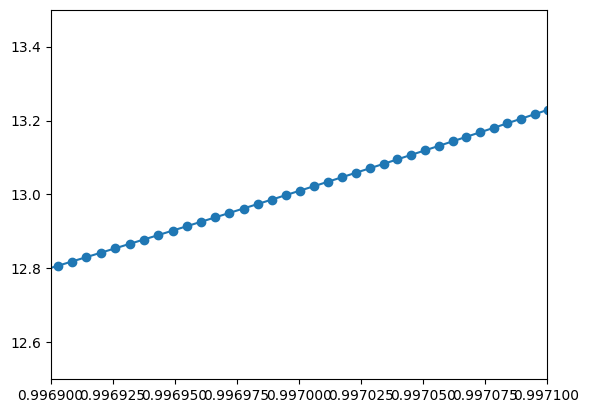

In [345]:
#plt.scatter(Es, Ls, c=vals[:, :, 0])
#h = plt.contourf(Emesh, Lmesh, vals[:,:, 0])#, levels=rats)
#plt.axis('scaled')
#plt.colorbar()
#plt.scatter(Emesh, Lmesh, s=0.0002)
print(a)
E1, L1, E2, L2 = mm.get_EL_curve(a, 0.0, npts=5000, rmax=1000)
#get_EL_curve(a, 0.0, rmax=max(100.0, L_test**2 + C_test), npts=5000)
plt.plot(E1, L1)
plt.scatter(E1, L1)
#plt.plot(E2, L2)
plt.xlim(0.997-1e-4, 0.997+1e-4)
plt.ylim(12.5, 13.5)
plt.show()



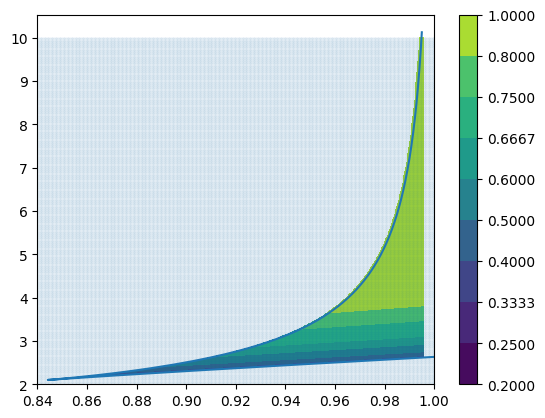

In [160]:
#plt.scatter(Es, Ls, c=vals[:, :, 0])
h = plt.contourf(Emesh, Lmesh, vals[:,:, 0]/vals[:,:, 2], levels=rats)
#plt.axis('scaled')
plt.colorbar()
plt.scatter(Emesh, Lmesh, s=0.0002)
E1, L1, E2, L2 = mm.get_EL_curve(a, 0.0)
plt.plot(E1, L1)
#plt.plot(E2, L2)
#plt.xlim(0.83, 0.9)
#plt.ylim(2, 3)
plt.show()

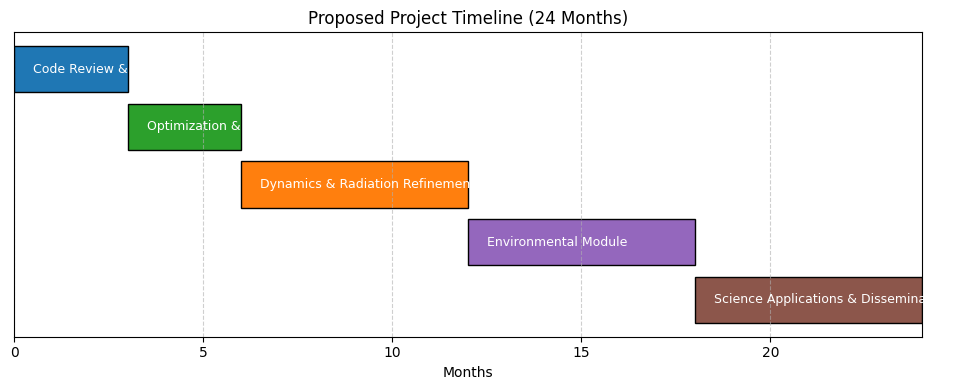

In [892]:
import matplotlib.pyplot as plt

# Define tasks and durations (in months)
tasks = [
    ("Code Review & Stabilization", 0, 3),
    ("Optimization & Refactoring", 3, 6),
    ("Dynamics & Radiation Refinement", 6, 12),
    ("Environmental Module", 12, 18),
    ("Science Applications & Dissemination", 18, 24)
]

# Create figure
fig, ax = plt.subplots(figsize=(10, 4))

# Colors (optional)
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#8c564b"]

# Plot each task as a bar
for i, (task, start, end) in enumerate(tasks):
    ax.barh(i, end - start, left=start, color=colors[i], edgecolor='black')
    ax.text(start + 0.5, i, task, va='center', ha='left', color='white', fontsize=9)

# Format
ax.set_yticks([])
ax.set_xlim(0, 24)
ax.set_xlabel("Months")
ax.set_title("Proposed Project Timeline (24 Months)")
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


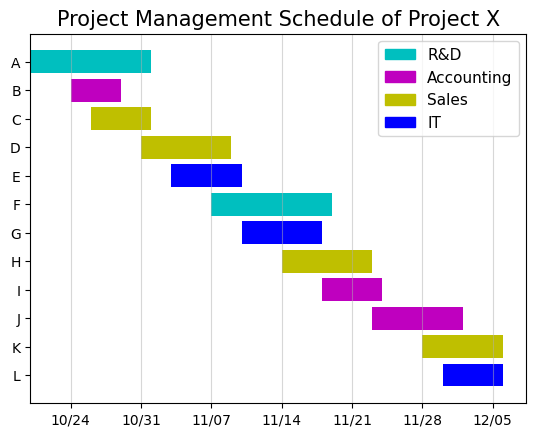

In [903]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import datetime as dt

df = pd.DataFrame({'task': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L'],
                  'team': ['R&D', 'Accounting', 'Sales', 'Sales', 'IT', 'R&D', 'IT', 'Sales', 'Accounting', 'Accounting', 'Sales', 'IT'],
                  'start': pd.to_datetime(['20 Oct 2022', '24 Oct 2022', '26 Oct 2022', '31 Oct 2022', '3 Nov 2022', '7 Nov 2022', '10 Nov 2022', '14 Nov 2022', '18 Nov 2022', '23 Nov 2022', '28 Nov 2022', '30 Nov 2022']),
                  'end': pd.to_datetime(['31 Oct 2022', '28 Oct 2022', '31 Oct 2022', '8 Nov 2022', '9 Nov 2022', '18 Nov 2022', '17 Nov 2022', '22 Nov 2022', '23 Nov 2022', '1 Dec 2022', '5 Dec 2022', '5 Dec 2022']),
                  'completion_frac': [1, 1, 1, 1, 1, 0.95, 0.7, 0.35, 0.1, 0, 0, 0]})
df['days_to_start'] = (df['start'] - df['start'].min()).dt.days
df['days_to_end'] = (df['end'] - df['start'].min()).dt.days
df['task_duration'] = df['days_to_end'] - df['days_to_start'] + 1  # to include also the end date
df['completion_days'] = df['completion_frac'] * df['task_duration']
#print(df)
# 1
team_colors = {'R&D': 'c', 'Accounting': 'm', 'Sales': 'y', 'IT': 'b'}

patches = []
for team in team_colors:
    patches.append(matplotlib.patches.Patch(color=team_colors[team]))

fig, ax = plt.subplots()
for index, row in df.iterrows():
    plt.barh(y=row['task'], width=row['task_duration'], left=row['days_to_start'] + 1, color=team_colors[row['team']])
plt.title('Project Management Schedule of Project X', fontsize=15)
plt.gca().invert_yaxis()
xticks = np.arange(5, df['days_to_end'].max() + 2, 7)
xticklabels = pd.date_range(start=df['start'].min() + dt.timedelta(days=4), end=df['end'].max()).strftime("%m/%d")
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels[::7])
ax.xaxis.grid(True, alpha=0.5)

# Adding a legend
ax.legend(handles=patches, labels=team_colors.keys(), fontsize=11)

plt.show()

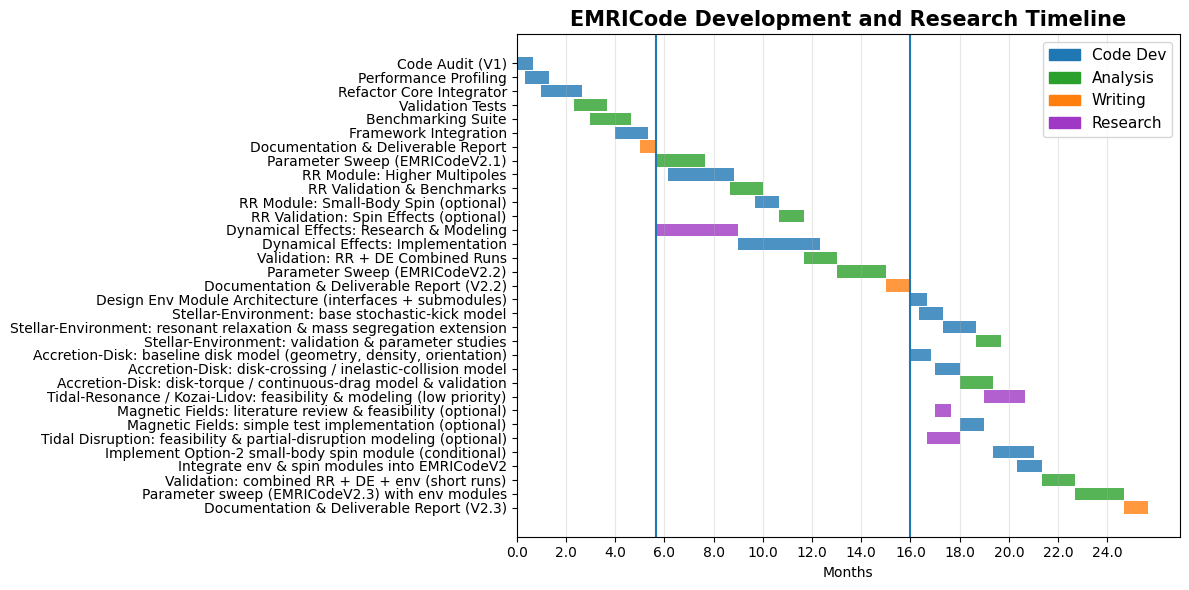

In [1038]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import datetime as dt

# === Define EMRICode Project Phases ===
df = pd.DataFrame({
    'task': ['Baseline Code Validation',
             'Radiation-Reaction Refinement',
             'Optimization & Performance Profiling',
             'Modular Architecture Integration',
             'Validation & Testing of Modular Components',
             'First Deliverable (Paper 1)',
             'Extended Radiation-Reaction (Higher Multipoles)',
             'Multi-Physics & Environmental Modules',
             'Scalability & Benchmarking on Clusters',
             'Second Deliverable (Paper 2)',
             'Full-Scale Simulations & Waveform Extraction',
             'Final Synthesis & Public Release (Paper 3)'],
    'category': ['Code Dev', 'Code Dev', 'Code Dev',
                 'Code Dev', 'Code Dev','Code Dev',
                 'Analysis','Analysis', 'Analysis',
                 'Writing', 'Writing', 'Writing'],
    'days_until_start': [0, 60, 120, 180, 300, 360, 390, 450, 540, 660, 690, 810],
    'task_duration': [90, 120, 120, 150, 90, 30, 120, 150, 120, 30, 120, 60]
})

df_phase1 = pd.DataFrame({
    'task': [
        'Code Audit (V1)',
        'Performance Profiling',
        'Refactor Core Integrator',
        'Validation Tests',
        'Benchmarking Suite',
        'Framework Integration',
        'Documentation & Deliverable Report'
    ],
    'category': [
        'Code Dev',
        'Code Dev',
        'Code Dev',
        'Analysis',
        'Analysis',
        'Code Dev',
        'Writing'
    ],
    'days_until_start': [0, 10, 30, 70, 90, 120, 150],
    'task_duration': [20, 30, 50, 40, 50, 40, 20]
})

df_phase2 = pd.DataFrame({
    'task': [
        'Parameter Sweep (EMRICodeV2.1)',
        'RR Module: Higher Multipoles',
        'RR Validation & Benchmarks',
        'RR Module: Small-Body Spin (optional)',
        'RR Validation: Spin Effects (optional)',
        'Dynamical Effects: Research & Modeling',
        'Dynamical Effects: Implementation',
        'Validation: RR + DE Combined Runs',
        'Parameter Sweep (EMRICodeV2.2)',
        'Documentation & Deliverable Report (V2.2)'
    ],
    'category': [
        'Analysis',
        'Code Dev',
        'Analysis',
        'Code Dev',
        'Analysis',
        'Research',
        'Code Dev',
        'Analysis',
        'Analysis',
        'Writing'
    ],
    'days_until_start': np.array([0, 15, 90, 120, 150, 0, 100, 180, 220, 280])
        + df_phase1['days_until_start'].iloc[-1]
        + df_phase1['task_duration'].iloc[-1],
    'task_duration': [60, 80, 40, 30, 30, 100, 100, 40, 60, 30]
})


df_phase3 = pd.DataFrame({
    'task': [
        'Design Env Module Architecture (interfaces + submodules)',
        'Stellar-Environment: base stochastic-kick model',
        'Stellar-Environment: resonant relaxation & mass segregation extension',
        'Stellar-Environment: validation & parameter studies',
        'Accretion-Disk: baseline disk model (geometry, density, orientation)',
        'Accretion-Disk: disk-crossing / inelastic-collision model',
        'Accretion-Disk: disk-torque / continuous-drag model & validation',
        'Tidal-Resonance / Kozai-Lidov: feasibility & modeling (low priority)',
        'Magnetic Fields: literature review & feasibility (optional)',
        'Magnetic Fields: simple test implementation (optional)',
        'Tidal Disruption: feasibility & partial-disruption modeling (optional)',
        'Implement Option-2 small-body spin module (conditional)',
        'Integrate env & spin modules into EMRICodeV2',
        'Validation: combined RR + DE + env (short runs)',
        'Parameter sweep (EMRICodeV2.3) with env modules',
        'Documentation & Deliverable Report (V2.3)'
    ],
    'category': [
        'Code Dev',   # architecture
        'Code Dev',   # base kicks
        'Code Dev',   # resonant & mass-seg extension
        'Analysis',   # validation
        'Code Dev',   # disk base
        'Code Dev',   # disk-crossing
        'Analysis',   # disk torque validation
        'Research',   # Kozai-Lidov / tidal resonance
        'Research',   # mag review
        'Code Dev',   # mag test
        'Research',   # tidal disruption
        'Code Dev',   # spin
        'Code Dev',   # integration
        'Analysis',   # validation
        'Analysis',   # parameter sweep
        'Writing'     # documentation
    ],
    'days_until_start': np.array([
        0,   10,  40,  80,   0,  30,  60,  90,
        30,  60,  20, 100, 130, 160, 200, 260
    ]) + df_phase2['days_until_start'].iloc[-1] + df_phase2['task_duration'].iloc[-1],
    'task_duration': [
        20,  30,  40,  30,  25,  30,  40,  50,
        20,  30,  40,  50,  30,  40,  60,  30
    ]
})


df = pd.concat([df_phase1, df_phase2, df_phase3])
# === Derived Columns ===
df['days_until_end'] = df['days_until_start'] + df['task_duration']

# === Category Colors ===
category_colors = {
    'Code Dev':'#1f77b4',  # blue
    'Analysis': '#2ca02c',  # green
    'Writing': '#ff7f0e',    # orange
    'Research': "#9f38c4"   #purple
}

patches = [matplotlib.patches.Patch(color=c, label=cat) for cat, c in category_colors.items()]

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 6))
for index, row in df.iterrows():
    # Full task bar
    ax.barh(y=row['task'], width=row['task_duration'], left=row['days_until_start'],
            color=category_colors[row['category']], alpha=0.8, height=0.9)

# === Formatting ===
ax.set_title('EMRICode Development and Research Timeline', fontsize=15, weight='bold')
ax.invert_yaxis()

xticks = np.arange(0, df['days_until_end'].max() + 7, 30)
#xticklabels = pd.date_range(start=df['days_until_start'].min(), end=df['end'].max()).strftime("%b %d")
ax.set_xticks(xticks[::2])
ax.set_xticklabels(xticks[::2]/30)
for phase_end in [170, 170+280+30]:
    ax.axvline(phase_end)
ax.xaxis.grid(True, alpha=0.3)

ax.legend(handles=patches, fontsize=11)
ax.set_xlabel('Months')
plt.tight_layout()
plt.show()


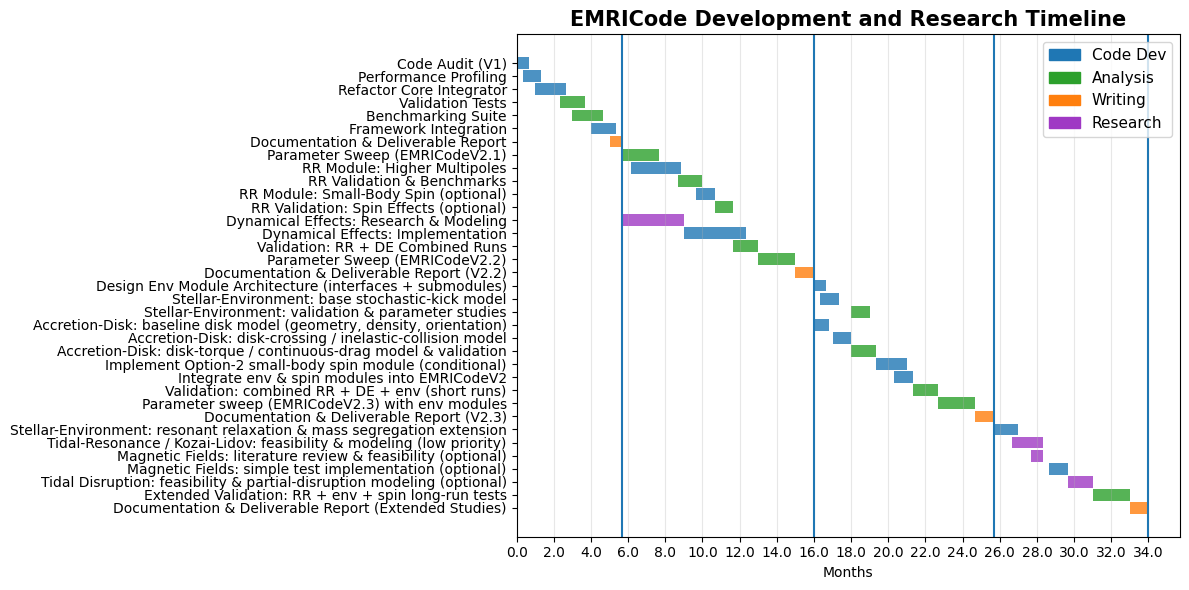

In [1039]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import datetime as dt

# ----- PHASE 1 -----
# Audit of EMRICodeV1, initialization of EMRICodeV2
df_phase1 = pd.DataFrame({
    'task': [
        'Code Audit (V1)',
        'Performance Profiling',
        'Refactor Core Integrator',
        'Validation Tests',
        'Benchmarking Suite',
        'Framework Integration',
        'Documentation & Deliverable Report'
    ],
    'category': [
        'Code Dev', 'Code Dev', 'Code Dev',
        'Analysis', 'Analysis', 'Code Dev', 'Writing'
    ],
    'days_until_start': [0, 10, 30, 70, 90, 120, 150],
    'task_duration': [20, 30, 50, 40, 50, 40, 20]
})

# ----- PHASE 2 -----
# Initial module expansion for EMRICodeV2: Radiation Reaction (Higher Multipoles (and optional Small Body Spin) and Dynamical Effects Modules
df_phase2 = pd.DataFrame({
    'task': [
        'Parameter Sweep (EMRICodeV2.1)',
        'RR Module: Higher Multipoles',
        'RR Validation & Benchmarks',
        'RR Module: Small-Body Spin (optional)',
        'RR Validation: Spin Effects (optional)',
        'Dynamical Effects: Research & Modeling',
        'Dynamical Effects: Implementation',
        'Validation: RR + DE Combined Runs',
        'Parameter Sweep (EMRICodeV2.2)',
        'Documentation & Deliverable Report (V2.2)'
    ],
    'category': [
        'Analysis', 'Code Dev', 'Analysis', 'Code Dev', 'Analysis',
        'Research', 'Code Dev', 'Analysis', 'Analysis', 'Writing'
    ],
    'days_until_start': np.array(
        [0, 15, 90, 120, 150, 0, 100, 180, 220, 280]
    ) + df_phase1['days_until_start'].iloc[-1] + df_phase1['task_duration'].iloc[-1],
    'task_duration': [60, 80, 40, 30, 30, 100, 100, 40, 60, 30]
})

# ----- PHASE 3 -----
# Secondary module expansion for EMRICodeV2: Environmental Effects(Stellar Environment, Accretion Disk) and conditional Radiation Reaction (Small Body Spin) modules
df_phase3 = pd.DataFrame({
    'task': [
        'Design Env Module Architecture (interfaces + submodules)',
        'Stellar-Environment: base stochastic-kick model',
        'Stellar-Environment: validation & parameter studies',
        'Accretion-Disk: baseline disk model (geometry, density, orientation)',
        'Accretion-Disk: disk-crossing / inelastic-collision model',
        'Accretion-Disk: disk-torque / continuous-drag model & validation',
        'Implement Option-2 small-body spin module (conditional)',
        'Integrate env & spin modules into EMRICodeV2',
        'Validation: combined RR + DE + env (short runs)',
        'Parameter sweep (EMRICodeV2.3) with env modules',
        'Documentation & Deliverable Report (V2.3)'
    ],
    'category': [
        'Code Dev', 'Code Dev', 'Analysis',
        'Code Dev', 'Code Dev', 'Analysis',
        'Code Dev', 'Code Dev', 'Analysis', 'Analysis', 'Writing'
    ],
    'days_until_start': np.array(
        [0, 10, 60, 0, 30, 60, 100, 130, 160, 200, 260]
    ) + df_phase2['days_until_start'].iloc[-1] + df_phase2['task_duration'].iloc[-1],
    'task_duration': [20, 30, 30, 25, 30, 40, 50, 30, 40, 60, 30]
})

# ----- PHASE 4 -----
# Optional, exploratory, and low-priority expansions: Environmental Effects(Stellar Environment, Tidal Resonance, Magnetic Fields)
df_phase4 = pd.DataFrame({
    'task': [
        'Stellar-Environment: resonant relaxation & mass segregation extension',
        'Tidal-Resonance / Kozai-Lidov: feasibility & modeling (low priority)',
        'Magnetic Fields: literature review & feasibility (optional)',
        'Magnetic Fields: simple test implementation (optional)',
        'Tidal Disruption: feasibility & partial-disruption modeling (optional)',
        'Extended Validation: RR + env + spin long-run tests',
        'Documentation & Deliverable Report (Extended Studies)'
    ],
    'category': [
        'Code Dev', 'Research', 'Research', 'Code Dev', 'Research', 'Analysis', 'Writing'
    ],
    'days_until_start': np.array(
        [0, 30, 60, 90, 120, 160, 220]
    ) + df_phase3['days_until_start'].iloc[-1] + df_phase3['task_duration'].iloc[-1],
    'task_duration': [40, 50, 20, 30, 40, 60, 30]
})

df = pd.concat([df_phase1, df_phase2, df_phase3, df_phase4])
# === Derived Columns ===
df['days_until_end'] = df['days_until_start'] + df['task_duration']

# === Category Colors ===
category_colors = {
    'Code Dev':'#1f77b4',  # blue
    'Analysis': '#2ca02c',  # green
    'Writing': '#ff7f0e',    # orange
    'Research': "#9f38c4"   #purple
}

patches = [matplotlib.patches.Patch(color=c, label=cat) for cat, c in category_colors.items()]

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 6))
for index, row in df.iterrows():
    # Full task bar
    ax.barh(y=row['task'], width=row['task_duration'], left=row['days_until_start'],
            color=category_colors[row['category']], alpha=0.8, height=0.9)

# === Formatting ===
ax.set_title('EMRICode Development and Research Timeline', fontsize=15, weight='bold')
ax.invert_yaxis()

xticks = np.arange(0, df['days_until_end'].max() + 7, 30)
#xticklabels = pd.date_range(start=df['days_until_start'].min(), end=df['end'].max()).strftime("%b %d")
ax.set_xticks(xticks[::2])
ax.set_xticklabels(xticks[::2]/30)
for phase in [df_phase1, df_phase2, df_phase3, df_phase4]:
    ax.axvline(phase['days_until_start'].iloc[-1] + phase['task_duration'].iloc[-1])    
ax.xaxis.grid(True, alpha=0.3)

ax.legend(handles=patches, fontsize=11)
ax.set_xlabel('Months')
plt.tight_layout()
plt.show()


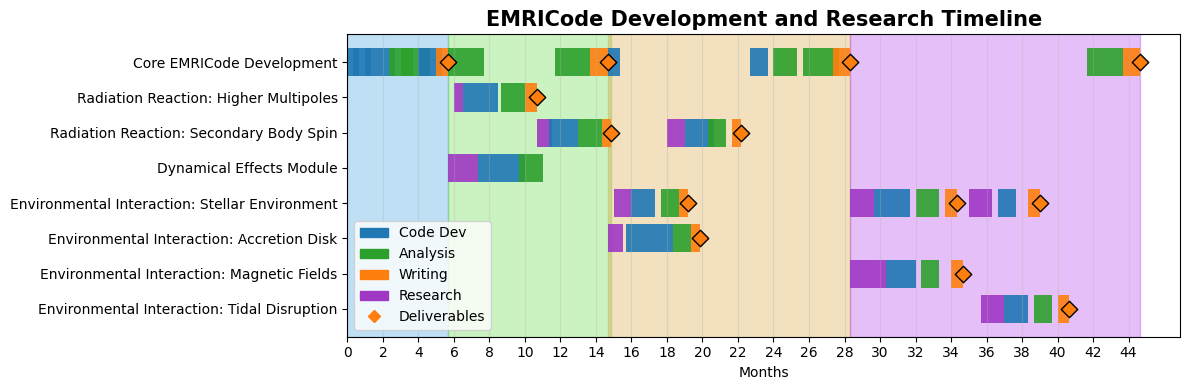

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# === (Your existing data creation blocks unchanged) ===
# ----- PHASE 1 -----
# Audit of EMRICodeV1, initialization of EMRICodeV2
df_phase1 = pd.DataFrame({
    'task': [
        'Code Audit (V1)',
        'Performance Profiling',
        'Refactor Core Integrator',
        'Validation Tests',
        'Benchmarking Suite',
        'Framework Integration',
        'Documentation & Deliverable Report'
    ],
    'category': [
        'Code Dev', 'Code Dev', 'Code Dev',
        'Analysis', 'Analysis', 'Code Dev', 'Writing'
    ],
    'module': [
        'Core', 'Core', 'Core',
        'Core', 'Core', 'Core', 'Core'
    ],
    'days_until_start': [0, 10, 30, 70, 90, 120, 150],
    'task_duration': [20, 30, 50, 40, 50, 40, 20],
})

# ----- PHASE 2 -----
# Radiation Reaction (Higher Multipoles, optional Small-Body Spin) + Dynamical Effects Modules
df_phase2 = pd.DataFrame({
    'task': [
        # Baseline & Higher Multipoles
        'Parameter Sweep (EMRICodeV2.1)',
        'RR: Higher Multipoles — Research',
        'RR: Higher Multipoles — Implementation',
        'RR: Higher Multipoles — Validation & Analysis',
        'RR: Higher Multipoles — Deliverable',
        # Small Body Spin Option 1
        'RR: Small-Body Spin (Option 1) — Research (optional)',
        'RR: Small-Body Spin (Option 1) — Implementation (optional)',
        'RR: Small-Body Spin (Option 1) — Validation & Analysis (optional)',
        'RR: Small-Body Spin (Option 1) — Writing (optional)',
        # Dynamical Effects
        'Dynamical Effects — Research',
        'Dynamical Effects — Implementation',
        'Dynamical Effects — Validation & Benchmarks',
        # Combined & Wrap-up
        'Parameter Sweep (EMRICodeV2.2)',
        'Documentation & Deliverable Report (V2.2)'
    ],
    'category': [
        'Analysis', 'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Analysis',
        'Analysis', 'Writing'
    ],
    'module': [
        'Core', 'Multipole', 'Multipole', 'Multipole', 'Multipole',
        'Spin', 'Spin', 'Spin', 'Spin',
        'Dynamic', 'Dynamic', 'Dynamic',
        'Core', 'Core'
    ],
    'days_until_start': np.array([
        0, 10, 25, 90, 130,
        150, 170, 220, 260,
        0, 50, 120,
        180, 240
    ]) + df_phase1['days_until_start'].iloc[-1] + df_phase1['task_duration'].iloc[-1],
    'task_duration': [
        60, 15, 60, 40, 20,
        25, 50, 40, 15,
        50, 80, 40,
        60, 30
    ],
})

# ----- PHASE 3 -----
# Environmental Interactions (Stellar Env, Accretion Disk, optional Spin Option 2)
df_phase3 = pd.DataFrame({
    'task': [
        # Architecture
        'Design Environmental Module Architecture (interfaces + submodules)',
        # Stellar Environment (Stochastic Kicks)
        'Stellar Env (Stochastic Kicks) — Research',
        'Stellar Env (Stochastic Kicks) — Implementation',
        'Stellar Env (Stochastic Kicks) — Validation & Analysis',
        'Stellar Env (Stochastic Kicks) — Deliverable',
        # Accretion Disk
        'Accretion Disk — Research',
        'Accretion Disk — Implementation I: Collision Model',
        'Accretion Disk — Implementation II: Drag/Torque',
        'Accretion Disk — Validation & Analysis',
        'Accretion Disk — Deliverable',
        # Spin Option 2
        'RR: Small-Body Spin (Option 2) — Research (conditional)',
        'RR: Small-Body Spin (Option 2) — Implementation (conditional)',
        'RR: Small-Body Spin (Option 2) — Validation (conditional)',
        'RR: Small-Body Spin (Option 2) — Writing (conditional)',
        # Integration & Sweeps
        'Integration: Env + Spin Modules',
        'Validation: RR + DE + Env Combined Runs',
        'Parameter Sweep (EMRICodeV2.3)',
        'Documentation & Deliverable Report (V2.3)'
    ],
    'category': [
        'Code Dev',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Code Dev', 'Analysis', 'Analysis', 'Writing'
    ],
    'module': [
        'Core',
        'StellEnv', 'StellEnv', 'StellEnv', 'StellEnv',
        'AccDisk', 'AccDisk', 'AccDisk', 'AccDisk', 'AccDisk',
        'Spin', 'Spin', 'Spin', 'Spin',
        'Core', 'Core', 'Core', 'Core'
    ],
    'days_until_start': np.array([
        0,
        10, 40, 90, 120,
        0, 30, 70, 110, 140,
        100, 130, 170, 210,
        240, 280, 330, 380
    ]) + df_phase2['days_until_start'].iloc[-1] + df_phase2['task_duration'].iloc[-1],
    'task_duration': [
        20,
        30, 40, 30, 15,
        25, 40, 40, 30, 15,
        30, 50, 30, 15,
        30, 40, 60, 30
    ],
})

# ----- PHASE 4 -----
# Optional & Exploratory Modules (Resonant Relaxation, Magnetic Fields, Tidal Disruption)
df_phase4 = pd.DataFrame({
    'task': [
        # Resonant Relaxation + Mass Segregation
        'Stellar Env (Resonant Relaxation + Mass Segregation) — Research',
        'Stellar Env (Resonant Relaxation + Mass Segregation) — Implementation',
        'Stellar Env (Resonant Relaxation + Mass Segregation) — Analysis',
        'Stellar Env (Resonant Relaxation + Mass Segregation) — Deliverable',
        # Tidal Resonance
        'Stellar Env (Tidal Resonance (Kozai-Lidov)) — Research',
        'Stellar Env (Tidal Resonance (Kozai-Lidov)) — Modeling',
        'Stellar Env (Tidal Resonance (Kozai-Lidov)) — Writing',
        # Magnetic Fields
        'Magnetic Field Interactions — Research (optional)',
        'Magnetic Field Interactions — Implementation (optional)',
        'Magnetic Field Interactions — Validation (optional)',
        'Magnetic Field Interactions — Writing (optional)',
        # Tidal Disruption
        'Tidal Disruption — Research (optional)',
        'Tidal Disruption — Implementation (optional)',
        'Tidal Disruption — Analysis (optional)',
        'Tidal Disruption — Writing (optional)',
        # Extended Validation & Wrap-up
        'Extended Validation: Full-Code Long-Run Tests',
        'Documentation & Deliverable Report (Extended Studies)'
    ],
    'category': [
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Writing',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Analysis', 'Writing'
    ],
    'module': [
        'StellEnv', 'StellEnv', 'StellEnv', 'StellEnv',
        'StellEnv', 'StellEnv', 'StellEnv',
        'MagField', 'MagField', 'MagField', 'MagField',
        'Tidal', 'Tidal', 'Tidal', 'Tidal',
        'Core', 'Core'
    ],
    'days_until_start': np.array([
        0, 40, 110, 160,
        200, 250, 300,
        0, 60, 120, 170,
        220, 260, 310, 350,
        400, 460
    ]) + df_phase3['days_until_start'].iloc[-1] + df_phase3['task_duration'].iloc[-1],
    'task_duration': [
        40, 60, 40, 20,
        40, 30, 20,
        60, 50, 30, 20,
        40, 40, 30, 20,
        60, 30
    ],
})

# ----- Combine & finalize -----
for df in [df_phase1, df_phase2, df_phase3, df_phase4]:
    df['days_until_end'] = df['days_until_start'] + df['task_duration']

df = pd.concat([df_phase1, df_phase2, df_phase3, df_phase4], ignore_index=True)

def module_rename(mod):
    if mod == 'Core':
        return 'Core EMRICode Development'
    elif mod == 'Multipole':
        return 'Radiation Reaction: Higher Multipoles'
    elif mod == 'Spin':
        return 'Radiation Reaction: Secondary Body Spin'
    elif mod == 'Dynamic':
        return 'Dynamical Effects Module'
    elif mod == 'StellEnv':
        return 'Environmental Interaction: Stellar Environment'
    elif mod == 'AccDisk':
        return 'Environmental Interaction: Accretion Disk'
    elif mod == 'MagField':
        return 'Environmental Interaction: Magnetic Fields'
    elif mod == 'Tidal':
        return 'Environmental Interaction: Tidal Disruption'
    else:
        return 'Other'

df['module'] = df['module'].apply(module_rename)

# === Category colors ===
category_colors = {
    'Code Dev': '#1f77b4',  # blue
    'Analysis': '#2ca02c',  # green
    'Writing': '#ff7f0e',   # orange
    'Research': "#9f38c4"   # purple
}

# === Phase vertical bands ===
phase_bounds = []
phases = [df_phase1, df_phase2, df_phase3, df_phase4]
for i, ph in enumerate(phases, start=1):
    start = ph['days_until_start'].min()
    end = ph['days_until_end'].max()
    phase_bounds.append((start, end, f'Phase {i}'))

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 4))

# Add vertical bands for phases
phase_colors = ["#2995dd", "#53d433", "#d59a2b", "#ab2de6"]
for (start, end, label), color in zip(phase_bounds, phase_colors):
    ax.axvspan(start, end, color=color, alpha=0.3, zorder=0)

# === Plot module-family rows with colored segments for each category ===
modules = df['module'].unique()[::-1]
for i, module in enumerate(modules):
    module_df = df[df['module'] == module]
    for _, row in module_df.iterrows():
        ax.barh(
            y=module,
            width=row['task_duration'],
            left=row['days_until_start'],
            color=category_colors.get(row['category'], 'gray'),
            height=0.8,
            alpha=0.9
        )

# === Deliverable milestones (D) ===
deliverables = df[df['category'].str.contains('Writing', case=False, regex=True)]
ax.scatter(deliverables['days_until_end'], deliverables['module'],
           marker='D', s=70, color='#ff7f0e', edgecolor='black', zorder=3)

# === Formatting ===
ax.set_title('EMRICode Development and Research Timeline', fontsize=15, weight='bold')
ax.set_xlabel('Months')
ax.set_xticks(np.arange(0, df['days_until_end'].max() + 30, 60))
ax.set_xticklabels((np.arange(0, df['days_until_end'].max() + 30, 60) / 30).astype(int))
#ax.invert_yaxis()

patches = [matplotlib.patches.Patch(color=c, label=cat) for cat, c in category_colors.items()]
ax.legend(handles=patches + [matplotlib.lines.Line2D([], [], color='#ff7f0e', marker='D', linestyle='None', label='Deliverables')],
          fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


6                     EMRICodeV2.1 Documentation Report
8                                Parameter Sweep Report
12                  RR: Higher Multipoles — Deliverable
16    RR: Small-Body Spin (Option 1) — Writing (opti...
21    Documentation & Parameter Sweep Comparison (V2.2)
26         Stellar Env (Stochastic Kicks) — Deliverable
31                         Accretion Disk — Deliverable
35    RR: Small-Body Spin (Option 2) — Writing (cond...
38        Documentation & Parameter Sweep Report (V2.3)
42    Stellar Env (Resonant Relaxation + Mass Segreg...
49     Magnetic Field Interactions — Writing (optional)
53                Tidal Disruption — Writing (optional)
45    Stellar Env (Tidal Resonance (Kozai-Lidov)) — ...
55    Documentation & Deliverable Report (Extended S...
Name: task, dtype: object


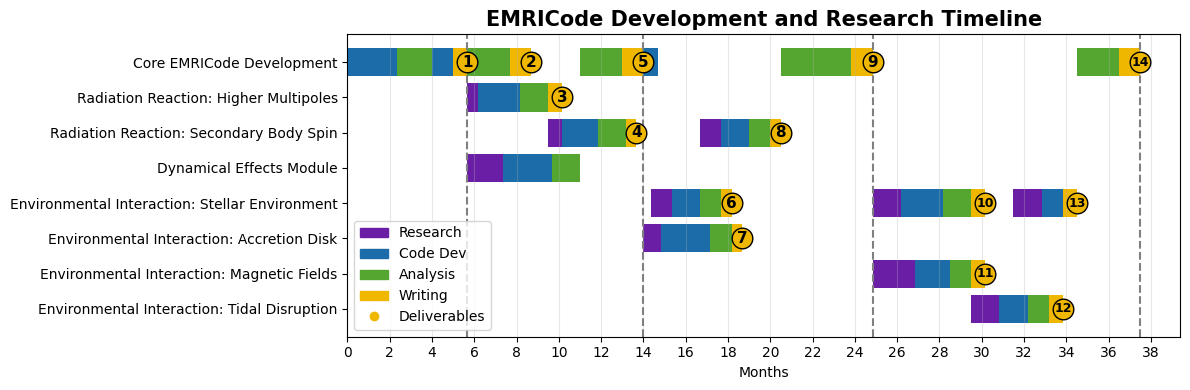

In [6]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# === (Your existing data creation blocks unchanged) ===
# ----- PHASE 1 -----
# Audit of EMRICodeV1, initialization of EMRICodeV2
df_phase1 = pd.DataFrame({
    'task': [
        'Code Audit (V1)',
        'Performance Profiling',
        'Refactor Core Integrator',
        'Validation Tests',
        'Benchmarking Suite',
        'Framework Integration',
        'EMRICodeV2.1 Documentation Report'
    ],
    'category': [
        'Code Dev', 'Code Dev', 'Code Dev',
        'Analysis', 'Analysis', 'Code Dev', 'Writing'
    ],
    'module': [
        'Core', 'Core', 'Core',
        'Core', 'Core', 'Core', 'Core'
    ],
    'days_until_start': [0, 10, 30, 70, 90, 120, 150],
    'task_duration': [20, 30, 50, 40, 50, 40, 20],
})

# ----- PHASE 2 -----
# Radiation Reaction (Higher Multipoles, optional Small-Body Spin) + Dynamical Effects Modules
df_phase2 = pd.DataFrame({
    'task': [
        # Baseline
        'Parameter Sweep (EMRICodeV2.1)',
        'Parameter Sweep Report',
        # Higher Multipoles
        'RR: Higher Multipoles — Research',
        'RR: Higher Multipoles — Implementation',
        'RR: Higher Multipoles — Validation & Analysis',
        'RR: Higher Multipoles — Deliverable',
        # Small Body Spin Option 1
        'RR: Small-Body Spin (Option 1) — Research (optional)',
        'RR: Small-Body Spin (Option 1) — Implementation (optional)',
        'RR: Small-Body Spin (Option 1) — Validation & Analysis (optional)',
        'RR: Small-Body Spin (Option 1) — Writing (optional)',
        # Dynamical Effects
        'Dynamical Effects — Research',
        'Dynamical Effects — Implementation',
        'Dynamical Effects — Validation & Benchmarks',
        # Combined & Wrap-up
        'Parameter Sweep (EMRICodeV2.2)',
        'Documentation & Parameter Sweep Comparison (V2.2)'
    ],
    'category': [
        'Analysis', 'Writing',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Analysis',
        'Analysis', 'Writing'
    ],
    'module': [
        'Core', 'Core',
        'Multipole', 'Multipole', 'Multipole', 'Multipole',
        'Spin', 'Spin', 'Spin', 'Spin',
        'Dynamic', 'Dynamic', 'Dynamic',
        'Core', 'Core'
    ],
    'days_until_start': np.array([
        0, 60,
        0, 15, 75, 115,
        115, 135, 185, 225,
        0, 50, 120,
        160, 220
    ]) + df_phase1['days_until_start'].iloc[-1] + df_phase1['task_duration'].iloc[-1],
    'task_duration': [
        60, 30,
        15, 60, 40, 20,
        25, 50, 40, 15,
        50, 80, 40,
        60, 30
    ],
})

# ----- PHASE 3 -----
# Environmental Interactions (Stellar Env, Accretion Disk, optional Spin Option 2)
df_phase3 = pd.DataFrame({
    'task': [
        # Architecture
        'Design Environmental Module Architecture (interfaces + submodules)',
        # Stellar Environment (Stochastic Kicks)
        'Stellar Env (Stochastic Kicks) — Research',
        'Stellar Env (Stochastic Kicks) — Implementation',
        'Stellar Env (Stochastic Kicks) — Validation & Analysis',
        'Stellar Env (Stochastic Kicks) — Deliverable',
        # Accretion Disk
        'Accretion Disk — Research',
        'Accretion Disk — Implementation I: Collision Model',
        'Accretion Disk — Implementation II: Drag/Torque',
        'Accretion Disk — Validation & Analysis',
        'Accretion Disk — Deliverable',
        # Spin Option 2
        'RR: Small-Body Spin (Option 2) — Research (conditional)',
        'RR: Small-Body Spin (Option 2) — Implementation (conditional)',
        'RR: Small-Body Spin (Option 2) — Validation (conditional)',
        'RR: Small-Body Spin (Option 2) — Writing (conditional)',
        # Integration & Sweeps
        #'Integration: Env + Spin Modules',   #The whole point of modularity is that I don't need extra integration time
        'Validation: RR + DE + Env Combined Runs',
        'Parameter Sweep (EMRICodeV2.3)',
        'Documentation & Parameter Sweep Report (V2.3)'
    ],
    'category': [
        'Code Dev',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Analysis', 'Analysis', 'Writing'
    ],
    'module': [
        'Core',
        'StellEnv', 'StellEnv', 'StellEnv', 'StellEnv',
        'AccDisk', 'AccDisk', 'AccDisk', 'AccDisk', 'AccDisk',
        'Spin', 'Spin', 'Spin', 'Spin',
        'Core', 'Core', 'Core'
    ],
    'days_until_start': np.array([
        0,
        10, 40, 80, 110,
        0, 25, 65, 95, 125,
        80, 110, 150, 180,
        195, 235, 295
    ]) + df_phase2['days_until_start'].iloc[-1] + df_phase2['task_duration'].iloc[-1],
    'task_duration': [
        20,
        30, 40, 30, 15,
        25, 40, 40, 30, 15,
        30, 50, 30, 15,
        40, 60, 30
    ],
})

# ----- PHASE 4 -----
# Optional & Exploratory Modules (Resonant Relaxation, Magnetic Fields, Tidal Disruption)
df_phase4 = pd.DataFrame({
    'task': [
        # Resonant Relaxation + Mass Segregation
        'Stellar Env (Resonant Relaxation + Mass Segregation) — Research',
        'Stellar Env (Resonant Relaxation + Mass Segregation) — Implementation',
        'Stellar Env (Resonant Relaxation + Mass Segregation) — Analysis',
        'Stellar Env (Resonant Relaxation + Mass Segregation) — Deliverable',
        # Tidal Resonance
        'Stellar Env (Tidal Resonance (Kozai-Lidov)) — Research',
        'Stellar Env (Tidal Resonance (Kozai-Lidov)) — Modeling',
        'Stellar Env (Tidal Resonance (Kozai-Lidov)) — Writing',
        # Magnetic Fields
        'Magnetic Field Interactions — Research (optional)',
        'Magnetic Field Interactions — Implementation (optional)',
        'Magnetic Field Interactions — Validation (optional)',
        'Magnetic Field Interactions — Writing (optional)',
        # Tidal Disruption
        'Tidal Disruption — Research (optional)',
        'Tidal Disruption — Implementation (optional)',
        'Tidal Disruption — Analysis (optional)',
        'Tidal Disruption — Writing (optional)',
        # Extended Validation & Wrap-up
        'Extended Validation: Full-Code Long-Run Tests',
        'Documentation & Deliverable Report (Extended Studies)'
    ],
    'category': [
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Writing',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Research', 'Code Dev', 'Analysis', 'Writing',
        'Analysis', 'Writing'
    ],
    'module': [
        'StellEnv', 'StellEnv', 'StellEnv', 'StellEnv',
        'StellEnv', 'StellEnv', 'StellEnv',
        'MagField', 'MagField', 'MagField', 'MagField',
        'Tidal', 'Tidal', 'Tidal', 'Tidal',
        'Core', 'Core'
    ],
    'days_until_start': np.array([
        0, 40, 100, 140,
        200, 240, 270,
        0, 60, 110, 140,
        140, 180, 220, 250,
        290, 350
    ]) + df_phase3['days_until_start'].iloc[-1] + df_phase3['task_duration'].iloc[-1],
    'task_duration': [
        40, 60, 40, 20,
        40, 30, 20,
        60, 50, 30, 20,
        40, 40, 30, 20,
        60, 30
    ],
})

# ----- Combine & finalize -----
for df in [df_phase1, df_phase2, df_phase3, df_phase4]:
    df['days_until_end'] = df['days_until_start'] + df['task_duration']

df = pd.concat([df_phase1, df_phase2, df_phase3, df_phase4], ignore_index=True)

def module_rename(mod):
    if mod == 'Core':
        return 'Core EMRICode Development'
    elif mod == 'Multipole':
        return 'Radiation Reaction: Higher Multipoles'
    elif mod == 'Spin':
        return 'Radiation Reaction: Secondary Body Spin'
    elif mod == 'Dynamic':
        return 'Dynamical Effects Module'
    elif mod == 'StellEnv':
        return 'Environmental Interaction: Stellar Environment'
    elif mod == 'AccDisk':
        return 'Environmental Interaction: Accretion Disk'
    elif mod == 'MagField':
        return 'Environmental Interaction: Magnetic Fields'
    elif mod == 'Tidal':
        return 'Environmental Interaction: Tidal Disruption'
    else:
        return 'Other'

df['module'] = df['module'].apply(module_rename)

# === Category colors ===
category_colors = {
    'Research': "#9f38c4",   # purple
    'Code Dev': '#1f77b4',  # blue
    'Analysis': '#2ca02c',  # green
    'Writing': '#ff7f0e'   # orange
}

category_colors = {
    'Research': '#6A1Ea5',  # deep wine (dark)
    'Code Dev':  '#1B6CA8', # strong blue (medium-dark)
    'Analysis':  '#55A630', # vivid green (medium-light)
    'Writing':   '#EFB700'  # gold (light)
}

# === Phase vertical bands ===
phase_bounds = []
phases = [df_phase1, df_phase2, df_phase3, df_phase4]
for i, ph in enumerate(phases, start=1):
    start = ph['days_until_start'].min()
    end = ph['days_until_end'].max()
    phase_bounds.append((start, end, f'Phase {i}'))

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 4))

# Add vertical bands for phases

phase_colors = ["#2995dd", "#53d433", "#d59a2b", "#ab2de6"]
for (start, end, label), color in zip(phase_bounds, phase_colors):
    ax.axvline(end, color='gray', linestyle="--")
    #ax.axvspan(start, end, color=color, alpha=0.3, zorder=0)

# === Plot module-family rows with colored segments for each category ===
modules = df['module'].unique()[::-1]
for i, module in enumerate(modules):
    module_df = df[df['module'] == module]
    for _, row in module_df.iterrows():
        ax.barh(
            y=module,
            width=row['task_duration'],
            left=row['days_until_start'],
            color=category_colors.get(row['category'], 'gray'),
            height=0.8,
            alpha=1.0
        )

# === Deliverable milestones (D) ===
deliverables = df[df['category'].str.contains('Writing', case=False, regex=True)].copy()
deliverables = deliverables.sort_values(by='days_until_end')
deliverables['marker'] = [f"{i+1:02d}" for i in range(len(deliverables))]
print(deliverables["task"])
ax.scatter(deliverables['days_until_end'], deliverables['module'],
            s=220, color= category_colors["Writing"], edgecolor='black', zorder=3)
i = 0
for _, row in deliverables.iterrows():
    i += 1
    #ax.scatter(row['days_until_end'], row['module'], s=200, facecolor='none', edgecolor='black')
    ax.text(row['days_until_end'], row['module'], str(i),
            color='black', fontsize=11 - 2*(i//10), fontweight='bold',
            ha='center', va='center')



# === Formatting ===
ax.set_title('EMRICode Development and Research Timeline', fontsize=15, weight='bold')
ax.set_xlabel('Months')
ax.set_xticks(np.arange(0, df['days_until_end'].max() + 30, 60))
ax.set_xticklabels((np.arange(0, df['days_until_end'].max() + 30, 60) / 30).astype(int))
#ax.invert_yaxis()

patches = [matplotlib.patches.Patch(color=c, label=cat) for cat, c in category_colors.items()]
ax.legend(handles=patches + [matplotlib.lines.Line2D([], [], color=category_colors["Writing"], marker="o", linestyle='None', label='Deliverables')],
          fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


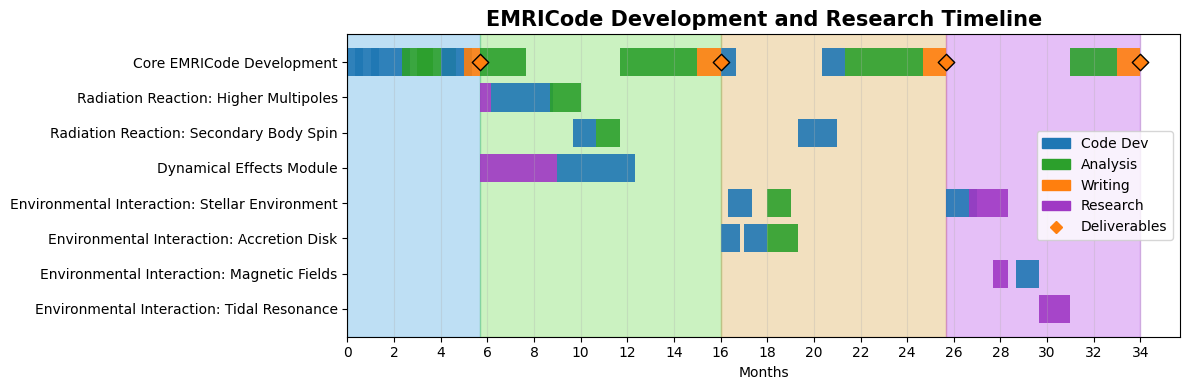

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# === (Your existing data creation blocks unchanged) ===
# ----- PHASE 1 -----
# Audit of EMRICodeV1, initialization of EMRICodeV2
df_phase1 = pd.DataFrame({
    'task': [
        'Code Audit (V1)',
        'Performance Profiling',
        'Refactor Core Integrator',
        'Validation Tests',
        'Benchmarking Suite',
        'Framework Integration',
        'Documentation & Deliverable Report'
    ],
    'category': [
        'Code Dev', 'Code Dev', 'Code Dev',
        'Analysis', 'Analysis', 'Code Dev', 'Writing'
    ],
    'module': [
        'Core', 'Core', 'Core',
        'Core', 'Core', 'Core', 'Core'
    ],
    'days_until_start': [0, 10, 30, 70, 90, 120, 150],
    'task_duration': [20, 30, 50, 40, 50, 40, 20],
})

# ----- PHASE 2 -----
# Initial module expansion for EMRICodeV2: Radiation Reaction (Higher Multipoles (and optional Small Body Spin) and Dynamical Effects Modules
df_phase2 = pd.DataFrame({
    'task': [
        'Parameter Sweep (EMRICodeV2.1)',
        'RR Module: Higher Multipoles Research',
        'RR Module: Higher Multipoles Implementation',
        'RR Validation & Benchmarks',
        'RR Module: Small-Body Spin (optional)',
        'RR Validation: Spin Effects (optional)',
        'Dynamical Effects: Research & Modeling',
        'Dynamical Effects: Implementation',
        'Validation: RR + DE Combined Runs',
        'Parameter Sweep (EMRICodeV2.2)',
        'Documentation & Deliverable Report (V2.2)'
    ],
    'category': [
        'Analysis', 'Research', 'Code Dev', 'Analysis', 'Code Dev', 'Analysis',
        'Research', 'Code Dev', 'Analysis', 'Analysis', 'Writing'
    ],
    'module': [
        'Core', 'Multipole', 'Multipole', 'Multipole', 'Spin', 'Spin',
        'Dynamic', 'Dynamic', 'Core', 'Core', 'Core'
    ],
    'days_until_start': np.array(
        [0, 0, 15, 90, 120, 150, 0, 100, 180, 220, 280]
    ) + df_phase1['days_until_start'].iloc[-1] + df_phase1['task_duration'].iloc[-1],
    'task_duration': [60, 15, 80, 40, 30, 30, 100, 100, 40, 60, 30],
})

# ----- PHASE 3 -----
# Secondary module expansion for EMRICodeV2: Environmental Effects(Stellar Environment, Accretion Disk) and conditional Radiation Reaction (Small Body Spin) modules
df_phase3 = pd.DataFrame({
    'task': [
        'Design Env Module Architecture (interfaces + submodules)',
        'Stellar-Environment: base stochastic-kick model',
        'Stellar-Environment: validation & parameter studies',
        'Accretion-Disk: baseline disk model (geometry, density, orientation)',
        'Accretion-Disk: disk-crossing / inelastic-collision model',
        'Accretion-Disk: disk-torque / continuous-drag model & validation',
        'Implement Option-2 small-body spin module (conditional)',
        'Integrate env & spin modules into EMRICodeV2',
        'Validation: combined RR + DE + env (short runs)',
        'Parameter sweep (EMRICodeV2.3) with env modules',
        'Documentation & Deliverable Report (V2.3)'
    ],
    'category': [
        'Code Dev', 'Code Dev', 'Analysis',
        'Code Dev', 'Code Dev', 'Analysis',
        'Code Dev', 'Code Dev', 'Analysis', 'Analysis', 'Writing'
    ],
    'module': [
        'Core', 'StellEnv', 'StellEnv',
        'AccDisk', 'AccDisk', 'AccDisk',
        'Spin', 'Core', 'Core', 'Core', 'Core'
    ],
    'days_until_start': np.array(
        [0, 10, 60, 0, 30, 60, 100, 130, 160, 200, 260]
    ) + df_phase2['days_until_start'].iloc[-1] + df_phase2['task_duration'].iloc[-1],
    'task_duration': [20, 30, 30, 25, 30, 40, 50, 30, 40, 60, 30]
})

# ----- PHASE 4 -----
# Optional, exploratory, and low-priority expansions: Environmental Effects(Stellar Environment, Tidal Disruption, Magnetic Fields)
df_phase4 = pd.DataFrame({
    'task': [
        'Stellar-Environment: resonant relaxation & mass segregation extension',
        'Stellar-Environment: Tidal-Resonance / Kozai-Lidov feasibility & modeling (low priority)',
        'Magnetic Fields: literature review & feasibility (optional)',
        'Magnetic Fields: simple test implementation (optional)',
        'Tidal Disruption: feasibility & partial-disruption modeling (optional)',
        'Extended Validation: RR + env + spin long-run tests',
        'Documentation & Deliverable Report (Extended Studies)'
    ],
    'category': [
        'Code Dev', 'Research', 'Research', 'Code Dev', 'Research', 'Analysis', 'Writing'
    ],
    'module': [
        'StellEnv', 'StellEnv', 'MagField', 'MagField', 'Tidal', 'Core', 'Core'
    ],
    'days_until_start': np.array(
        [0, 30, 60, 90, 120, 160, 220]
    ) + df_phase3['days_until_start'].iloc[-1] + df_phase3['task_duration'].iloc[-1],
    'task_duration': [40, 50, 20, 30, 40, 60, 30]
})

for df in [df_phase1, df_phase2, df_phase3, df_phase4]:
    df['days_until_end'] = df['days_until_start'] + df['task_duration']

# Combine all into master dataframe
df = pd.concat([df_phase1, df_phase2, df_phase3, df_phase4], ignore_index=True)

# === Define module families ===
def module_rename(mod):
    if mod == 'Core':
        return 'Core EMRICode Development'
    elif mod == 'Multipole':
        return 'Radiation Reaction: Higher Multipoles'
    elif mod == 'Spin':
        return 'Radiation Reaction: Secondary Body Spin'
    elif mod == 'Dynamic':
        return 'Dynamical Effects Module'
    elif mod == 'StellEnv':
        return 'Environmental Interaction: Stellar Environment'
    elif mod == 'AccDisk':
        return 'Environmental Interaction: Accretion Disk'
    elif mod == 'MagField':
        return 'Environmental Interaction: Magnetic Fields'
    elif mod == 'Tidal':
        return 'Environmental Interaction: Tidal Resonance'
    else:
        return 'Other'

df['module'] = df['module'].apply(module_rename)

# === Category colors ===
category_colors = {
    'Code Dev': '#1f77b4',  # blue
    'Analysis': '#2ca02c',  # green
    'Writing': '#ff7f0e',   # orange
    'Research': "#9f38c4"   # purple
}

# === Phase vertical bands ===
phase_bounds = []
phases = [df_phase1, df_phase2, df_phase3, df_phase4]
for i, ph in enumerate(phases, start=1):
    start = ph['days_until_start'].min()
    end = ph['days_until_end'].max()
    phase_bounds.append((start, end, f'Phase {i}'))

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 4))

# Add vertical bands for phases
phase_colors = ["#2995dd", "#53d433", "#d59a2b", "#ab2de6"]
for (start, end, label), color in zip(phase_bounds, phase_colors):
    ax.axvspan(start, end, color=color, alpha=0.3, zorder=0)

# === Plot module-family rows with colored segments for each category ===
modules = df['module'].unique()[::-1]
for i, module in enumerate(modules):
    module_df = df[df['module'] == module]
    for _, row in module_df.iterrows():
        ax.barh(
            y=module,
            width=row['task_duration'],
            left=row['days_until_start'],
            color=category_colors.get(row['category'], 'gray'),
            height=0.8,
            alpha=0.9
        )

# === Deliverable milestones (D) ===
deliverables = df[df['task'].str.contains('Deliverable|Documentation', case=False, regex=True)]
ax.scatter(deliverables['days_until_end'], deliverables['module'],
           marker='D', s=70, color='#ff7f0e', edgecolor='black', zorder=3)

# === Formatting ===
ax.set_title('EMRICode Development and Research Timeline', fontsize=15, weight='bold')
ax.set_xlabel('Months')
ax.set_xticks(np.arange(0, df['days_until_end'].max() + 30, 60))
ax.set_xticklabels((np.arange(0, df['days_until_end'].max() + 30, 60) / 30).astype(int))
#ax.invert_yaxis()

patches = [matplotlib.patches.Patch(color=c, label=cat) for cat, c in category_colors.items()]
ax.legend(handles=patches + [matplotlib.lines.Line2D([], [], color='#ff7f0e', marker='D', linestyle='None', label='Deliverables')],
          fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3881: RuntimeWarning: invalid value encountered in sqrt
  sqrt_Y = np.sqrt(Y)
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3884: RuntimeWarning: invalid value encountered in divide
  return numer / denom
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3882: RuntimeWarning: invalid value encountered in sqrt
  denom = (r**2) * np.sqrt(r**3*(r - 3) - 2*a*(a*C - p*sqrt_Y))
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3889: RuntimeWarning: invalid value encountered in sqrt
  sqrt_Y = np.sqrt(Y)
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3892: RuntimeWarning: invalid value encountered in divide
  return numer / denom
c:\Users\camcinto\OneDrive - NASA\Documents\GitHub\Black-Hole-Stuff\MetricMathStreamline.py:3890: Runt

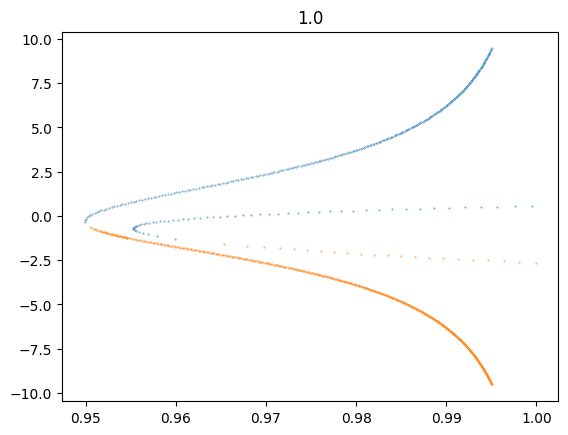

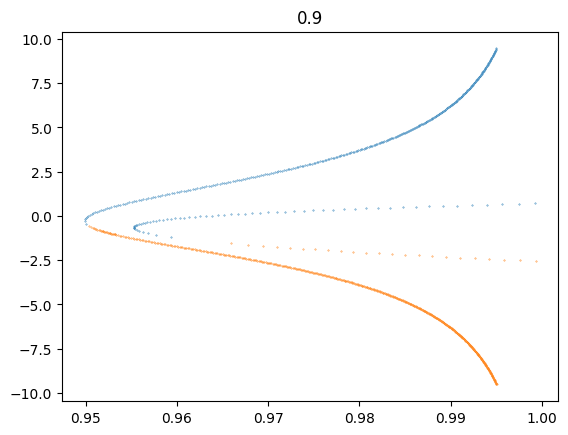

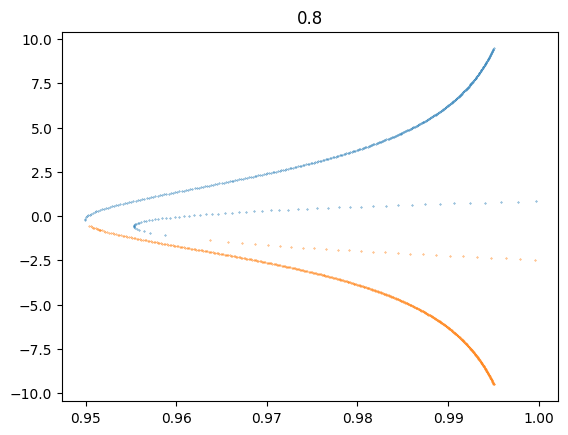

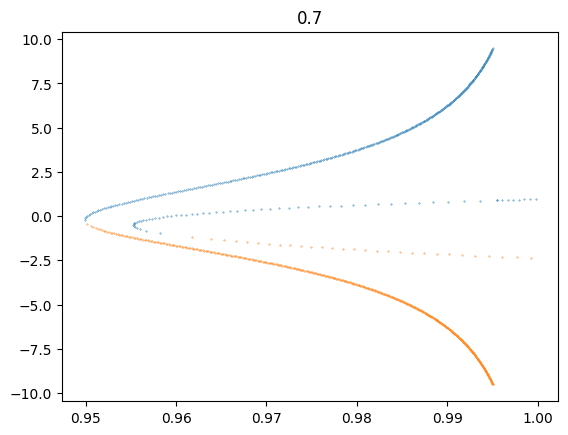

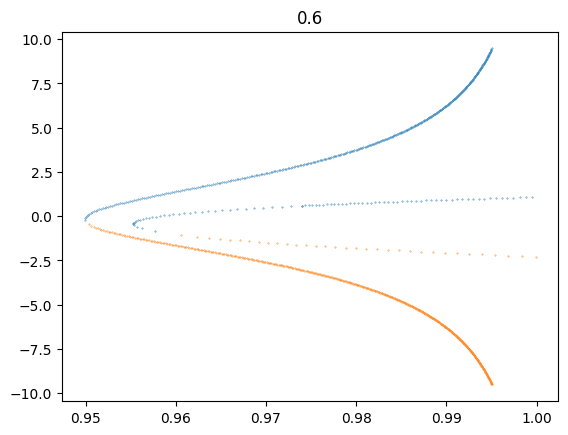

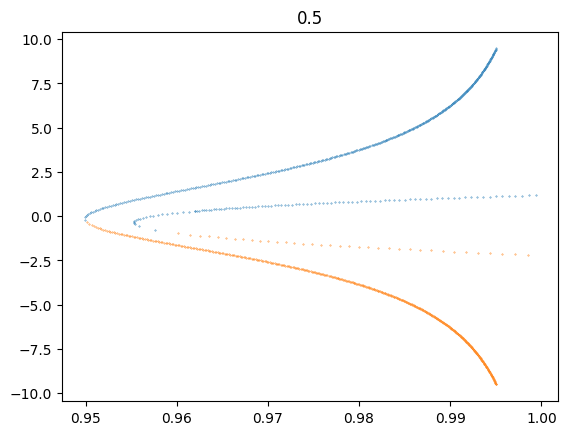

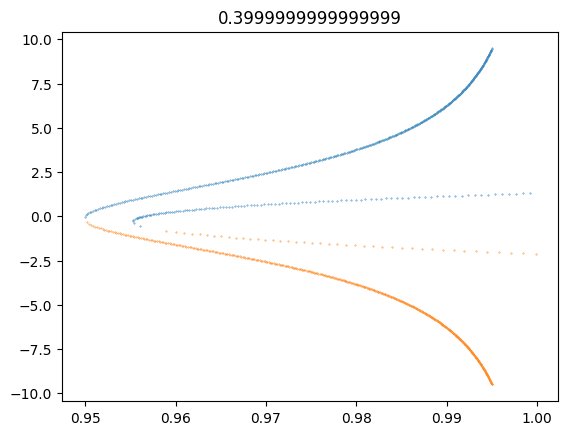

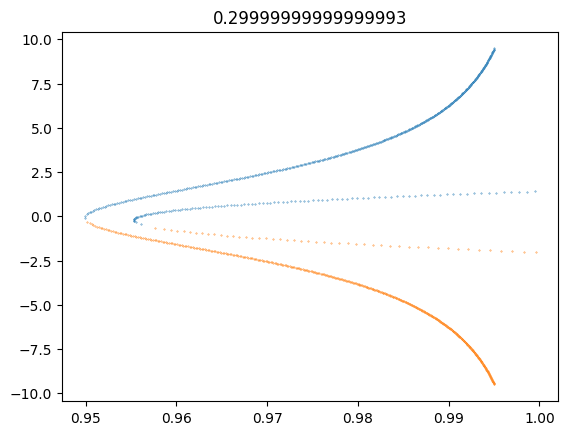

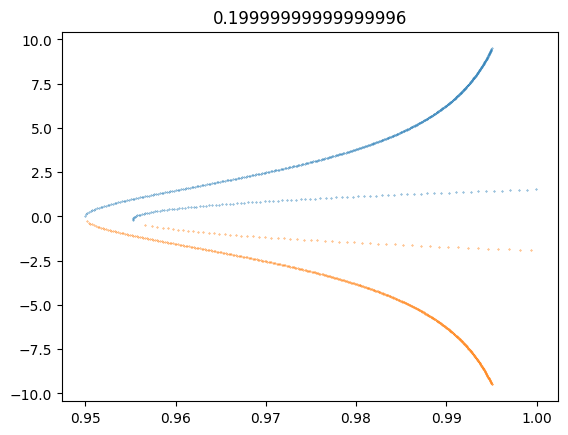

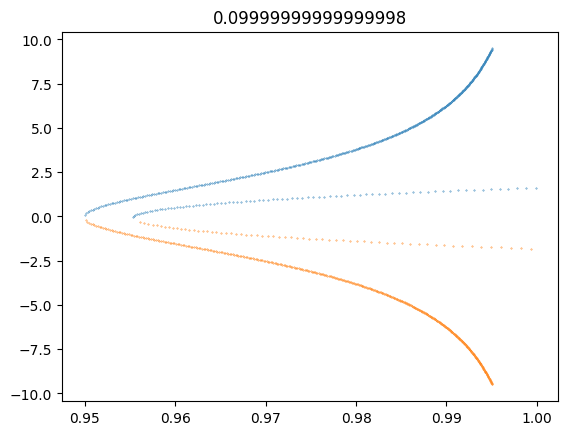

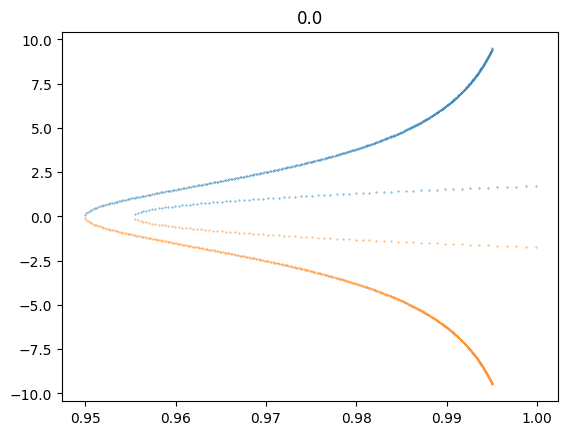

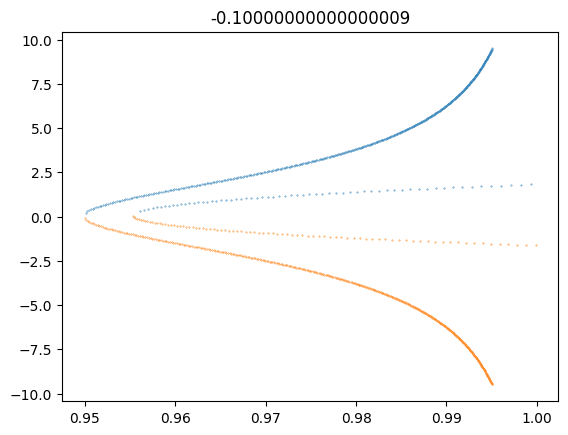

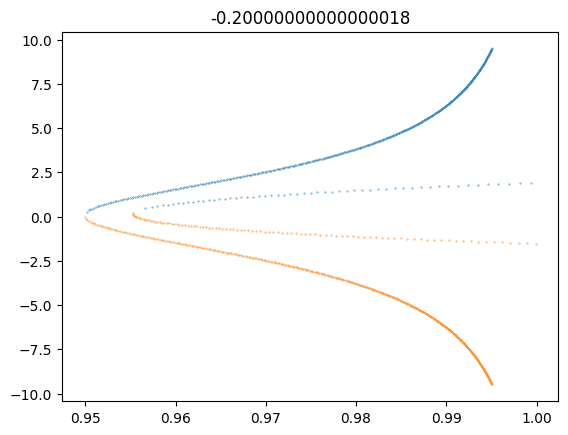

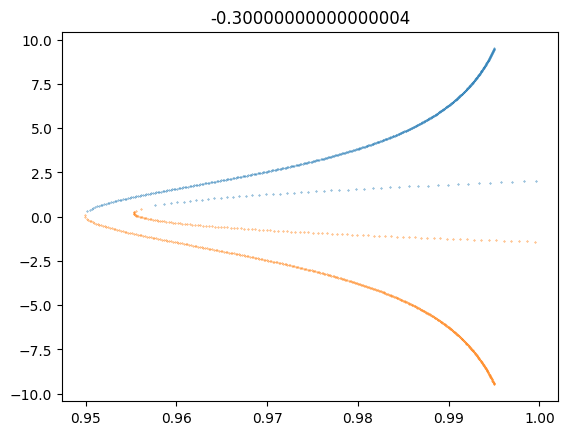

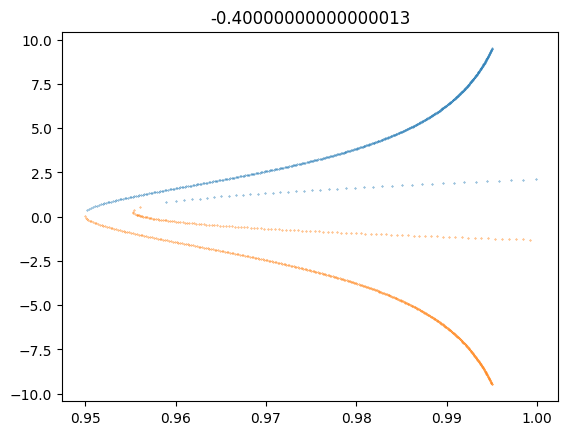

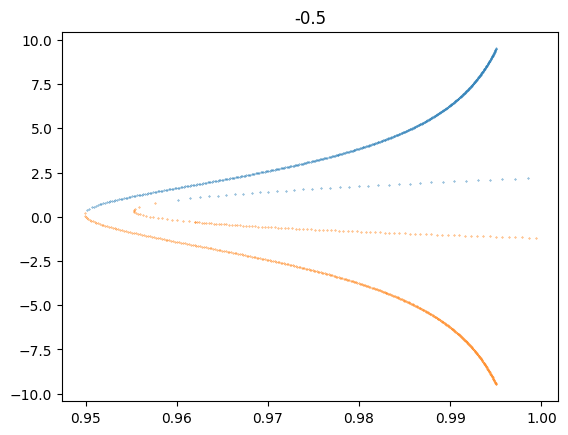

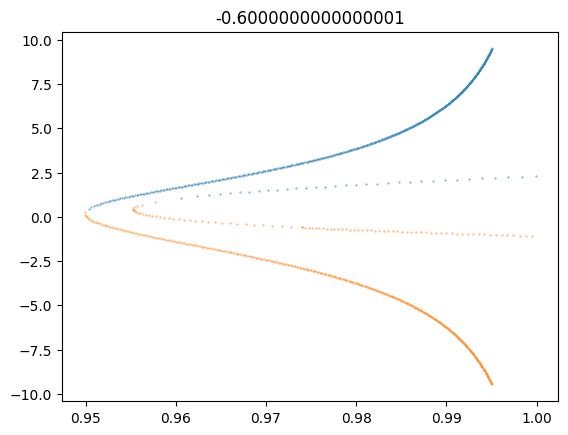

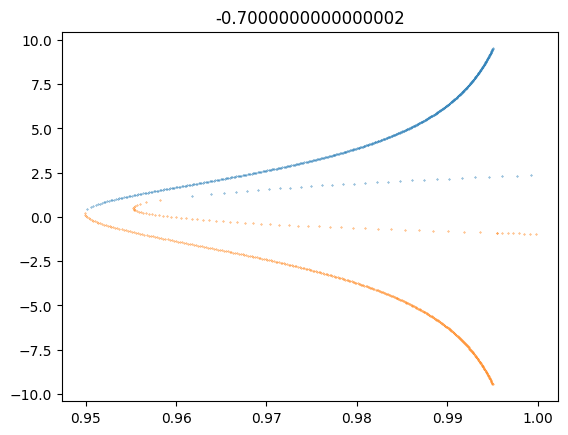

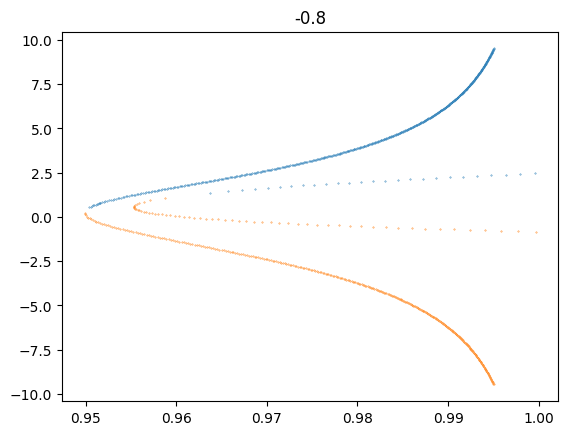

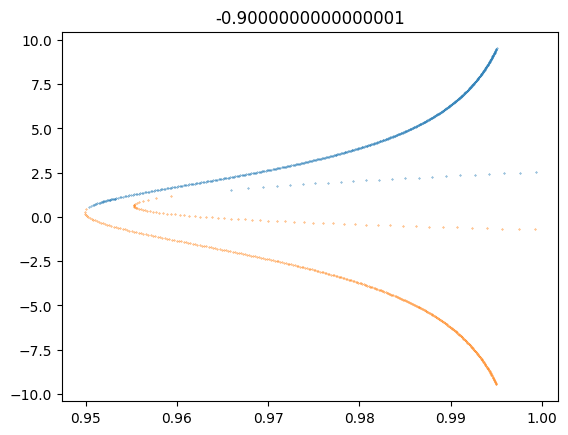

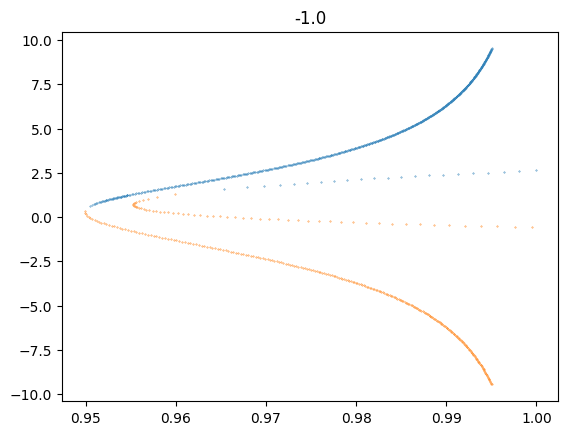

In [760]:
import MetricMathStreamline as mm
import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
importlib.reload(mm)

for a0 in np.linspace(1, -1, 21):
    E1, L1, E2, L2 = mm.get_EL_curve(a0, 13)
    plt.scatter(E1, L1, s=0.1)
    plt.scatter(E2, L2, s=0.1)
    plt.title(a0)
    #plt.xlim(0.8, 1.01)
    #plt.ylim(-10, 10)
    plt.show()

index 9 is out of bounds for axis 1 with size 9
borf 0.2704589366912842
(9, 10) (9, 10) (10, 9)


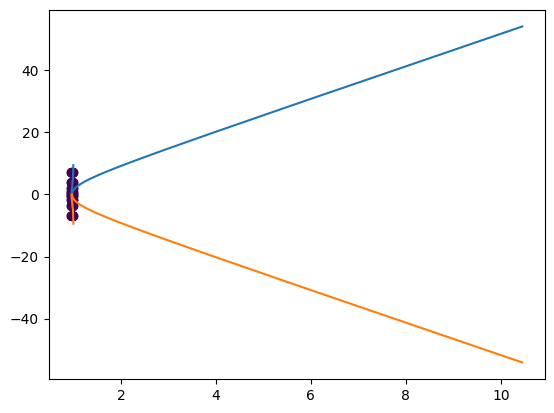

In [596]:
Es1 = np.linspace(0.954, 1.0, 10)
Ls1 = np.linspace(4.14, 20, 10)
Es1 = np.geomspace(0.954, 1.0, 10)
Ls1 = np.geomspace(1, 8, 5) - 1

Ls1 = np.unique(np.concatenate((Ls1, -Ls1)))
Emesh1, Lmesh1 = np.meshgrid(Es1, Ls1)

a, C = 0.0, 14
vals2 = np.zeros((len(Es1), len(Ls1)))
gorf = False
start = time.time()
for i in range(len(y)):
    if gorf == True:
        break
    for j in range(len(x)):
        if gorf == True:
            break
        #yprint(Es[j], Ls[i])
        try:
            if mm.is_in_ELC_region2(Emesh1[i, j], Lmesh1[i, j], C, a):
                vals2[i,j] = 1
            else:
                vals2[i,j] = 0
        except Exception as e:
            print(e)
            E1, L1, E2, L2 = mm.get_EL_curve(a, C)
            plt.plot(E1, L1)
            plt.plot(E2, L2)
            gorf = True
print("borf", time.time() - start)

print(np.shape(Emesh1), np.shape(Lmesh1), np.shape(vals2))
plt.scatter(Emesh1, Lmesh1, c=vals2)

In [733]:
import MetricMathStreamline as mm
import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
importlib.reload(mm)
C=14
lens = []
Es = np.random.uniform(0.954, 0.99, 100)
Ls = np.random.uniform(-6.3, 6.2, 100)
for i in range(100):
    start = time.time()
    mm.is_in_ELC_region3(Es[i], Ls[i], C, 0.9)
    end = time.time()
    lens.append(end-start)
# I NEED A BETTER WAY TO SET BOUNDS ON THE INITIAL R THING
print(np.mean(lens), np.std(lens), np.min(lens), np.max(lens))

0.04992213249206543 0.008966638288217624 0.03272652626037598 0.10130500793457031


In [741]:
import MetricMathStreamline as mm
import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
importlib.reload(mm)
C=14
lens = []
Es = np.random.uniform(0.954, 0.99, 100)
Ls = np.random.uniform(-6.3, 6.2, 100)
for i in range(100):
    start = time.time()
    mm.is_in_ELC_region3(Es[i], Ls[i], C, 0.9)
    end = time.time()
    lens.append(end-start)
# I NEED A BETTER WAY TO SET BOUNDS ON THE INITIAL R THING
print(np.mean(lens), np.std(lens), np.min(lens), np.max(lens))

0.039436445236206055 0.0072640522896975914 0.018243074417114258 0.08102893829345703


In [574]:
testy = np.reshape(np.random.random(16), (4, 4))
test = np.min(testy, axis=1)
print(testy)
print(test)
print(np.argmin(testy, axis=1))
print(np.argmin(testy))
dunk = np.argmin(testy, axis=1)
orf = np.reshape(np.arange(16), (4, 4))
print(orf)
print(orf[dunk])

[[0.07827896 0.60297237 0.38229527 0.47245367]
 [0.51885015 0.76786346 0.82695599 0.07209456]
 [0.05270765 0.84163448 0.48681284 0.19196538]
 [0.31176606 0.04678444 0.05395486 0.15539582]]
[0.07827896 0.07209456 0.05270765 0.04678444]
[0 3 0 1]
13
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[ 0  1  2  3]
 [12 13 14 15]
 [ 0  1  2  3]
 [ 4  5  6  7]]


In [587]:
test1 = np.arange(-10, 5)
test2 = np.arange(-5, 10)
np.concatenate((np.where(test1 >= 0)[0], np.where(test2 >= 0)[0]))
#np.concatenate((np.where(test1 < 0)[0], np.where(test2 < 0)[0]))

array([10, 11, 12, 13, 14,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

37


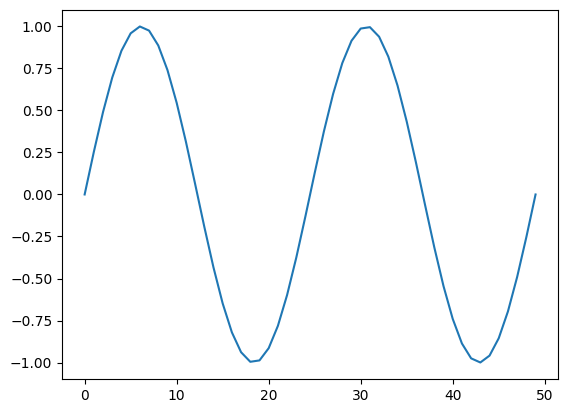

In [630]:
print(np.argmin(np.sin(np.linspace(0, 4*np.pi, 100))))
plt.plot(np.sin(np.linspace(0, 4*np.pi, 50)))

[28439 28863 28038 28867]
[1.04046603 0.96739626 1.03157648 0.96739339]
[[nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan nan nan nan nan]]


(0.9673, 0.96745)

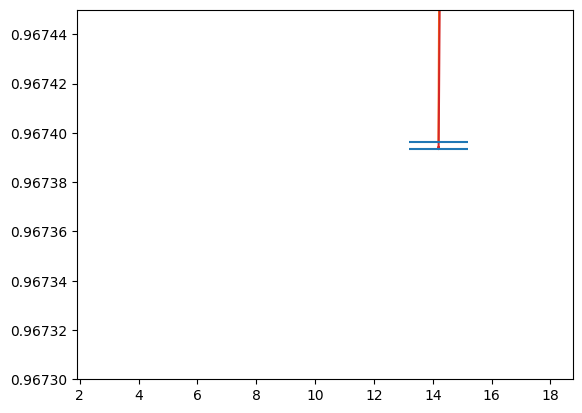

In [672]:
C_test, a = 18, -0.27
rys = [np.linspace(1, 6, 50000), np.linspace(max(12, C_test)/2, max(12, C_test), 50000)]

getEs = [mm.circE_C(rys[i%2], a, C_test, p=(-1)**(i//2)) for i in range(4)]
[plt.plot(rys[i%2], getEs[i]) for i in range(4)]

print(np.nanargmin(getEs, axis=1))
print(np.nanmin(getEs, axis=1))
ix = np.nanargmin(getEs, axis=1)
plt.hlines(np.nanmin(getEs, axis=1), [rys[i%2][ix[i]] - 1 for i in range(4)], [rys[i%2][ix[i]] + 1 for i in range(4)])
print(np.array(getEs)[:,:5])
plt.ylim(0.9673, 0.96745)
#plt.xlim(2,4)

In [675]:
print(test1)
print(test1 % 2 == 0)
print(sum(test1 % 2 == 0))

[-10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3   4]
[ True False  True False  True False  True False  True False  True False
  True False  True]
8


In [711]:
1 < 5 <3

False

In [735]:
np.array([np.arange(10) for i in range(4)])

array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])